In [22]:
!pip -q install datasets pandas

In [23]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset(
    "keerthanshetty/resume-skill-extractor-dataset"
)

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['title', 'source', 'job_description', 'summary', 'required_skills'],
        num_rows: 3050
    })
})


In [24]:
# Inspect Dataset Structure and Sample Records

df = dataset["train"].to_pandas()

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nNumber of unique job titles:", df["title"].nunique())

display(df.head())

Dataset shape: (3050, 5)

Columns:
['title', 'source', 'job_description', 'summary', 'required_skills']

Number of unique job titles: 1496


,title,source,job_description,summary,required_skills
0,Data Science Director,nathansutton,Altoida is a pioneer in developing digital bio...,The Director of Data Science will lead product...,"[Generative ML methods, Discriminative ML meth..."
1,Senior Data Scientist,nathansutton,Veeva Systems is a mission-driven organization...,This role is for a Data Scientist to shape the...,"[Natural Language Processing (NLP), Machine Le..."
2,Staff Data Scientist,nathansutton,"To get the best candidate experience, please c...",Slack is seeking an experienced data scientist...,"[SQL, Programming language for data analysis (..."
3,Sr Staff Data Scientist Ecosystem,nathansutton,About Pinterest: Millions of people across the...,This is a Senior Staff Data Scientist role for...,"[Quantitative modeling, Experimentation design..."
4,Staff Data Scientist Growth,nathansutton,About Pinterest: Millions of people across the...,This Staff Data Scientist role within Pinteres...,"[Scientific Methods, Web-scale Data Analysis, ..."


In [25]:
# Check Coverage of Target Career Areas

target_pattern = (
    r"data scientist|data science|data analyst|"
    r"healthcare analyst|healthcare data|health data|"
    r"clinical data|biomedical informatics|bioinformatics|"
    r"machine learning|business intelligence|bi analyst|"
    r"analytics"
)

relevant_jobs = df[
    df["title"].str.contains(
        target_pattern,
        case=False,
        na=False,
        regex=True
    )
].copy()

print("Total jobs in dataset:", len(df))
print("Potentially relevant jobs:", len(relevant_jobs))
print(
    "Percentage potentially relevant:",
    round(len(relevant_jobs) / len(df) * 100, 1),
    "%"
)

print("\nMost common relevant job titles:")
print(relevant_jobs["title"].value_counts().head(30))

Total jobs in dataset: 3050
Potentially relevant jobs: 2646
Percentage potentially relevant: 86.8 %

Most common relevant job titles:
title
Data Scientist                             400
Senior Data Scientist                      314
Lead Data Scientist                         48
Principal Data Scientist                    44
Sr Data Scientist                           44
Staff Data Scientist                        40
Data Science Manager                        39
Data Scientist Ii                           22
Senior Manager Data Science                 22
Senior Data Scientist Product Analytics     18
Director Data Science                       16
Director Of Data Science                    16
Data Science Intern                         16
Data Scientist Product Analytics            13
Senior Data Scientist Product               13
Data Scientist I                            11
Data Scientist Marketing                    11
Data Scientist Lead                         10
Manager Data S

In [26]:
# Check Duplicate Records Using Hashable Columns

print("Duplicate titles:")
print(df["title"].duplicated().sum())

print("\nDuplicate job descriptions:")
print(df["job_description"].duplicated().sum())

print("\nDuplicate title + description combinations:")
print(
    df.duplicated(
        subset=["title", "job_description"]
    ).sum()
)

Duplicate titles:
1554

Duplicate job descriptions:
0

Duplicate title + description combinations:
0


In [27]:
# Inspect Required Skills Data

print("Data type of first required_skills value:")
print(type(df["required_skills"].iloc[0]))

print("\nRequired skills for first 5 jobs:")
for i in range(5):
    print(f"\nJob: {df['title'].iloc[i]}")
    print(df["required_skills"].iloc[i])

skill_counts = df["required_skills"].apply(len)

print("\nRequired skills count summary:")
print(skill_counts.describe())

print("\nJobs with zero required skills:")
print((skill_counts == 0).sum())

Data type of first required_skills value:
<class 'numpy.ndarray'>

Required skills for first 5 jobs:

Job: Data Science Director
['Generative ML methods' 'Discriminative ML methods'
 'Contrastive ML methods' 'Classification techniques'
 'Gradient boosting techniques' 'Knowledge discovery' 'Causal inference'
 'Applied mathematics'
 'Statistics (Bayesian, Multi-Objective Optimization, Topological Data Analysis)'
 'AI' 'Machine Learning' 'Data quality management'
 'Data validation procedures' 'Data curation' 'Data documentation'
 'Data protection' 'Data storage' 'Model output calibration'
 'Data security protocols' 'Python (object-oriented development)'
 'Scientific Python packages' 'Statistical Python packages' 'SQL'
 'Programming languages' 'Quality Management Systems'
 'Healthcare data standards' 'HIPAA regulations']

Job: Senior Data Scientist
['Natural Language Processing (NLP)' 'Machine Learning' 'Deep Learning'
 'Large Language Models (LLMs)'
 'Transformer Architectures (e.g., GPT,

In [28]:
# Create Working Copy and Normalize Text Fields

jobs = df.copy()

# Convert required_skills from NumPy arrays to regular Python lists
jobs["required_skills"] = jobs["required_skills"].apply(list)

# Create normalized text fields for matching and retrieval
jobs["title_clean"] = (
    jobs["title"]
    .str.strip()
    .str.lower()
)

jobs["description_clean"] = (
    jobs["job_description"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .str.lower()
)

jobs["summary_clean"] = (
    jobs["summary"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .str.lower()
)

print("Working dataset shape:", jobs.shape)

display(
    jobs[
        ["title", "title_clean", "required_skills"]
    ].head()
)

Working dataset shape: (3050, 8)


,title,title_clean,required_skills
0,Data Science Director,data science director,"[Generative ML methods, Discriminative ML meth..."
1,Senior Data Scientist,senior data scientist,"[Natural Language Processing (NLP), Machine Le..."
2,Staff Data Scientist,staff data scientist,"[SQL, Programming language for data analysis (..."
3,Sr Staff Data Scientist Ecosystem,sr staff data scientist ecosystem,"[Quantitative modeling, Experimentation design..."
4,Staff Data Scientist Growth,staff data scientist growth,"[Scientific Methods, Web-scale Data Analysis, ..."


In [29]:
# Extract Seniority Level from Job Titles

import re

def get_seniority(title):
    title = title.lower()

    if re.search(r"\b(intern|internship)\b", title):
        return "Intern"
    elif re.search(r"\b(junior|jr\.?|entry level|associate)\b", title):
        return "Entry/Junior"
    elif re.search(r"\b(senior|sr\.?)\b", title):
        return "Senior"
    elif re.search(r"\b(staff|principal|lead)\b", title):
        return "Staff/Lead"
    elif re.search(r"\b(manager|director|head|vp|vice president)\b", title):
        return "Management"
    else:
        return "Mid/Unspecified"

jobs["seniority_level"] = jobs["title_clean"].apply(get_seniority)

print("Seniority distribution:")
print(jobs["seniority_level"].value_counts())

display(
    jobs[
        ["title", "seniority_level"]
    ].head(20)
)

Seniority distribution:
seniority_level
Mid/Unspecified    1115
Senior             1048
Staff/Lead          405
Management          359
Intern               75
Entry/Junior         48
Name: count, dtype: int64


,title,seniority_level
0,Data Science Director,Management
1,Senior Data Scientist,Senior
2,Staff Data Scientist,Staff/Lead
3,Sr Staff Data Scientist Ecosystem,Senior
4,Staff Data Scientist Growth,Staff/Lead
5,Staff Data Scientist Browse Discovery,Staff/Lead
6,Sr Data Scientist Search,Senior
7,Sr Data Scientist Growth,Senior
8,Senior Data Scientist,Senior
9,Lead Data Scientist,Staff/Lead


In [30]:
# Assign Seniority Alignment Scores

seniority_scores = {
    "Intern": 0.70,
    "Entry/Junior": 0.90,
    "Mid/Unspecified": 1.00,
    "Senior": 0.85,
    "Staff/Lead": 0.55,
    "Management": 0.35
}

jobs["seniority_alignment"] = jobs["seniority_level"].map(seniority_scores)

print("Seniority alignment summary:")
print(
    jobs.groupby("seniority_level")["seniority_alignment"]
    .first()
    .sort_values(ascending=False)
)

display(
    jobs[
        ["title", "seniority_level", "seniority_alignment"]
    ].head(20)
)

Seniority alignment summary:
seniority_level
Mid/Unspecified    1.00
Entry/Junior       0.90
Senior             0.85
Intern             0.70
Staff/Lead         0.55
Management         0.35
Name: seniority_alignment, dtype: float64


,title,seniority_level,seniority_alignment
0,Data Science Director,Management,0.35
1,Senior Data Scientist,Senior,0.85
2,Staff Data Scientist,Staff/Lead,0.55
3,Sr Staff Data Scientist Ecosystem,Senior,0.85
4,Staff Data Scientist Growth,Staff/Lead,0.55
5,Staff Data Scientist Browse Discovery,Staff/Lead,0.55
6,Sr Data Scientist Search,Senior,0.85
7,Sr Data Scientist Growth,Senior,0.85
8,Senior Data Scientist,Senior,0.85
9,Lead Data Scientist,Staff/Lead,0.55


In [31]:
# Define Candidate Career Profile

candidate_profile = {
    "education": [
        "MS Data Science and Analytics",
        "MS Business Analytics",
        "PhD Biochemistry",
        "MSc Clinical Microbiology",
        "BSc Medical Laboratory Technology"
    ],

    "skills": [
        "Python",
        "R",
        "SQL",
        "PySpark",
        "Tableau",
        "Power BI",
        "Excel",
        "KNIME",
        "Machine Learning",
        "Predictive Modeling",
        "Statistical Analysis",
        "Data Visualization",
        "Data Analysis",
        "Natural Language Processing",
        "LangChain",
        "ChromaDB",
        "Streamlit"
    ],

    "experience_areas": [
        "Data analytics",
        "Healthcare analytics",
        "Biomedical research",
        "Billing and transaction analytics",
        "Program evaluation",
        "Data cleaning and validation",
        "Predictive modeling",
        "Statistical analysis",
        "Research data analysis"
    ],

    "projects": [
        "Clinical decision support RAG system for type 2 diabetes",
        "Healthcare readmission prediction",
        "Billing reversal prediction",
        "Flight delay prediction using PySpark",
        "PubMedQA parameter-efficient fine-tuning",
        "Job matching and recommendation system"
    ],

    "career_interests": [
        "Data Scientist",
        "Data Analyst",
        "Healthcare Data Scientist",
        "Healthcare Data Analyst",
        "Biomedical Informatics",
        "Clinical Data",
        "Business Analytics"
    ]
}

candidate_profile

{'education': ['MS Data Science and Analytics',
  'MS Business Analytics',
  'PhD Biochemistry',
  'MSc Clinical Microbiology',
  'BSc Medical Laboratory Technology'],
 'skills': ['Python',
  'R',
  'SQL',
  'PySpark',
  'Tableau',
  'Power BI',
  'Excel',
  'KNIME',
  'Machine Learning',
  'Predictive Modeling',
  'Statistical Analysis',
  'Data Visualization',
  'Data Analysis',
  'Natural Language Processing',
  'LangChain',
  'ChromaDB',
  'Streamlit'],
 'experience_areas': ['Data analytics',
  'Healthcare analytics',
  'Biomedical research',
  'Billing and transaction analytics',
  'Program evaluation',
  'Data cleaning and validation',
  'Predictive modeling',
  'Statistical analysis',
  'Research data analysis'],
 'projects': ['Clinical decision support RAG system for type 2 diabetes',
  'Healthcare readmission prediction',
  'Billing reversal prediction',
  'Flight delay prediction using PySpark',
  'PubMedQA parameter-efficient fine-tuning',
  'Job matching and recommendation 

In [32]:
# Create Candidate Profile Chunks for Retrieval

profile_chunks = []

for section, items in candidate_profile.items():
    profile_chunks.append({
        "section": section,
        "content": "; ".join(items)
    })

profile_df = pd.DataFrame(profile_chunks)

print("Number of candidate profile chunks:", len(profile_df))

display(profile_df)

Number of candidate profile chunks: 5


,section,content
0,education,MS Data Science and Analytics; MS Business Ana...
1,skills,Python; R; SQL; PySpark; Tableau; Power BI; Ex...
2,experience_areas,Data analytics; Healthcare analytics; Biomedic...
3,projects,Clinical decision support RAG system for type ...
4,career_interests,Data Scientist; Data Analyst; Healthcare Data ...


In [33]:
# Define Job Search Preferences

job_preferences = {
    "preferred_roles": [
        "Data Scientist",
        "Data Analyst",
        "Healthcare Data Scientist",
        "Healthcare Data Analyst",
        "Biomedical Informatics",
        "Clinical Data",
        "Business Analytics"
    ],

    "preferred_locations": [
        "Phoenix, AZ",
        "Remote"
    ],

    "preferred_work_arrangements": [
        "Remote",
        "Hybrid"
    ],

    "preferred_job_types": [
        "Full-time"
    ],

    "salary_preference": None
}

job_preferences

{'preferred_roles': ['Data Scientist',
  'Data Analyst',
  'Healthcare Data Scientist',
  'Healthcare Data Analyst',
  'Biomedical Informatics',
  'Clinical Data',
  'Business Analytics'],
 'preferred_locations': ['Phoenix, AZ', 'Remote'],
 'preferred_work_arrangements': ['Remote', 'Hybrid'],
 'preferred_job_types': ['Full-time'],
 'salary_preference': None}

In [34]:
# Create Candidate Retrieval Query

candidate_query = " ".join([
    " ".join(candidate_profile["skills"]),
    " ".join(candidate_profile["experience_areas"]),
    " ".join(candidate_profile["projects"]),
    " ".join(candidate_profile["career_interests"]),
    " ".join(job_preferences["preferred_roles"])
])

print("Candidate retrieval query:")
print(candidate_query)

Candidate retrieval query:
Python R SQL PySpark Tableau Power BI Excel KNIME Machine Learning Predictive Modeling Statistical Analysis Data Visualization Data Analysis Natural Language Processing LangChain ChromaDB Streamlit Data analytics Healthcare analytics Biomedical research Billing and transaction analytics Program evaluation Data cleaning and validation Predictive modeling Statistical analysis Research data analysis Clinical decision support RAG system for type 2 diabetes Healthcare readmission prediction Billing reversal prediction Flight delay prediction using PySpark PubMedQA parameter-efficient fine-tuning Job matching and recommendation system Data Scientist Data Analyst Healthcare Data Scientist Healthcare Data Analyst Biomedical Informatics Clinical Data Business Analytics Data Scientist Data Analyst Healthcare Data Scientist Healthcare Data Analyst Biomedical Informatics Clinical Data Business Analytics


In [35]:
# Create Clean Candidate Retrieval Query

candidate_query_parts = (
    candidate_profile["skills"]
    + candidate_profile["experience_areas"]
    + candidate_profile["projects"]
    + job_preferences["preferred_roles"]
)

# Remove duplicate items while keeping the original order
candidate_query_parts = list(dict.fromkeys(candidate_query_parts))

candidate_query = " ".join(candidate_query_parts)

print("Candidate retrieval query:")
print(candidate_query)

Candidate retrieval query:
Python R SQL PySpark Tableau Power BI Excel KNIME Machine Learning Predictive Modeling Statistical Analysis Data Visualization Data Analysis Natural Language Processing LangChain ChromaDB Streamlit Data analytics Healthcare analytics Biomedical research Billing and transaction analytics Program evaluation Data cleaning and validation Predictive modeling Statistical analysis Research data analysis Clinical decision support RAG system for type 2 diabetes Healthcare readmission prediction Billing reversal prediction Flight delay prediction using PySpark PubMedQA parameter-efficient fine-tuning Job matching and recommendation system Data Scientist Data Analyst Healthcare Data Scientist Healthcare Data Analyst Biomedical Informatics Clinical Data Business Analytics


In [36]:
# Create Search Text for Each Job

jobs["skills_text"] = jobs["required_skills"].apply(
    lambda x: " ".join(x)
)

jobs["search_text"] = (
    jobs["title_clean"] + " "
    + jobs["summary_clean"] + " "
    + jobs["description_clean"] + " "
    + jobs["skills_text"].str.lower()
)

print("Example search text:")
print(jobs["search_text"].iloc[0][:1500])

Example search text:
data science director the director of data science will lead product strategies and develop the analytic vision and roadmap for altoida, a pioneer in digital biomarkers for neurological disease. this leadership role involves robust, end-to-end analytics, covering the data science life cycle and data engineering, while fostering a world-class culture of data analytics and machine learning. altoida is a pioneer in developing digital biomarkers of neurological disease using augmented reality and machine learning. our technology platform is designed to enable an objective evaluation of an individual’s neurological health, allowing for more accurate patient selection and stratification for clinical trials, as well as sensitive monitoring of disease progression. altoida’s mission is to provide life sciences companies with actionable insights using real-world data to increase the success rate for novel therapeutics, and usher in a new era of precision neurology using digi

In [37]:
# Install BM25 Package

!pip -q install rank-bm25

In [38]:
# Prepare Job Text and Candidate Query for BM25

import re
from rank_bm25 import BM25Okapi

def tokenize_text(text):
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z0-9+#.\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.split()

tokenized_jobs = jobs["search_text"].apply(tokenize_text).tolist()
tokenized_query = tokenize_text(candidate_query)

bm25 = BM25Okapi(tokenized_jobs)

print("Number of jobs indexed:", len(tokenized_jobs))
print("Number of query tokens:", len(tokenized_query))
print("\nFirst 30 query tokens:")
print(tokenized_query[:30])

Number of jobs indexed: 3050
Number of query tokens: 94

First 30 query tokens:
['python', 'r', 'sql', 'pyspark', 'tableau', 'power', 'bi', 'excel', 'knime', 'machine', 'learning', 'predictive', 'modeling', 'statistical', 'analysis', 'data', 'visualization', 'data', 'analysis', 'natural', 'language', 'processing', 'langchain', 'chromadb', 'streamlit', 'data', 'analytics', 'healthcare', 'analytics', 'biomedical']


In [39]:
# Retrieve Top Jobs Using BM25

import numpy as np

bm25_scores = bm25.get_scores(tokenized_query)

jobs["bm25_score"] = bm25_scores

bm25_top10 = (
    jobs
    .sort_values("bm25_score", ascending=False)
    .head(10)
    [
        [
            "title",
            "seniority_level",
            "bm25_score",
            "required_skills"
        ]
    ]
)

display(bm25_top10)

,title,seniority_level,bm25_score,required_skills
594,Senior Data Scientist,Senior,153.159164,"[Python, SAS, R, Mathematics, Statistics, Mode..."
1873,Director Data Science And Machine Learning,Management,150.078349,"[Python, SQL, Amazon Web Services (AWS), DataB..."
999,Data Scientist Insights Analytics,Mid/Unspecified,145.665811,"[Healthcare Analytics, BI, Data Science, SQL, ..."
262,Data Scientist,Mid/Unspecified,144.348610,"[Python, R, PySpark, Scala, Spark SQL, EMR dat..."
1838,Lead Analyst Data Science,Staff/Lead,143.535808,"[SQL, Tableau, Gitlab, Python, R, SAS, claims ..."
261,Principal Data Scientist,Staff/Lead,142.380125,"[Python, R, PySpark, Scala, Spark SQL, EMR dat..."
1988,Senior Data Scientist,Senior,141.148657,"[Python, R, PySpark, Scala, Spark SQL, Tableau..."
2741,Data Science Fellow Voice Video Analytics,Mid/Unspecified,140.661167,"[Python, Machine Learning, Computer Vision, Sp..."
154,Data Scientist,Mid/Unspecified,139.487561,"[Complex data management, Analytics, Statistic..."
2742,Data Science Fellow Nlp,Mid/Unspecified,139.482549,"[NLP, Machine Learning, Python]"


In [40]:
# Install Sentence Transformer Package

!pip -q install sentence-transformers

In [41]:
# Create Semantic Embeddings for Candidate and Jobs

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

job_embeddings = embedding_model.encode(
    jobs["search_text"].tolist(),
    show_progress_bar=True,
    normalize_embeddings=True
)

candidate_embedding = embedding_model.encode(
    [candidate_query],
    normalize_embeddings=True
)

semantic_scores = cosine_similarity(
    candidate_embedding,
    job_embeddings
)[0]

jobs["semantic_score"] = semantic_scores

print("Job embedding shape:", job_embeddings.shape)
print("Semantic scores calculated:", len(semantic_scores))

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/96 [00:00<?, ?it/s]

Job embedding shape: (3050, 384)
Semantic scores calculated: 3050


In [42]:
# Retrieve Top Jobs Using Semantic Similarity

semantic_top10 = (
    jobs
    .sort_values("semantic_score", ascending=False)
    .head(10)
    [
        [
            "title",
            "seniority_level",
            "semantic_score",
            "required_skills"
        ]
    ]
)

display(semantic_top10)

,title,seniority_level,semantic_score,required_skills
1607,Data Scientist,Mid/Unspecified,0.591894,"[SQL, Python, Pandas, Numpy, Matplotlib, Spark..."
1760,Senior Data Scientist,Senior,0.579150,"[Python, SQL, linux shell scripting, Amazon We..."
2231,Data Scientist Intern Summer,Intern,0.567754,"[Python, R, Tableau, SQL, Machine Learning, AI..."
1759,Staff Data Scientist,Staff/Lead,0.564740,"[Python, SQL, linux shell scripting, end-to-en..."
177,Senior Data Scientist Growth Personalization,Senior,0.563139,"[data mining, machine learning, statistical mo..."
2624,Data Scientist,Mid/Unspecified,0.562583,"[Python, SQL, Statistical modeling, Machine le..."
997,Data Scientist I,Mid/Unspecified,0.562281,"[SQL, Python, statistical methodologies, machi..."
154,Data Scientist,Mid/Unspecified,0.559327,"[Complex data management, Analytics, Statistic..."
1419,Data Scientist Care Management Analytics,Mid/Unspecified,0.557792,"[Tableau, SQL, R, Healthcare data analytics, M..."
1202,Data Scientist,Mid/Unspecified,0.557323,"[statistics, machine learning, business analys..."


In [43]:
# Compare BM25 and Semantic Retrieval Results

bm25_compare = (
    jobs.sort_values("bm25_score", ascending=False)
    .head(10)
    [["title", "seniority_level", "bm25_score"]]
    .reset_index(drop=True)
)

semantic_compare = (
    jobs.sort_values("semantic_score", ascending=False)
    .head(10)
    [["title", "seniority_level", "semantic_score"]]
    .reset_index(drop=True)
)

comparison = pd.DataFrame({
    "BM25 Rank": range(1, 11),
    "BM25 Job": bm25_compare["title"],
    "BM25 Seniority": bm25_compare["seniority_level"],
    "Semantic Rank": range(1, 11),
    "Semantic Job": semantic_compare["title"],
    "Semantic Seniority": semantic_compare["seniority_level"]
})

display(comparison)

,BM25 Rank,BM25 Job,BM25 Seniority,Semantic Rank,Semantic Job,Semantic Seniority
0,1,Senior Data Scientist,Senior,1,Data Scientist,Mid/Unspecified
1,2,Director Data Science And Machine Learning,Management,2,Senior Data Scientist,Senior
2,3,Data Scientist Insights Analytics,Mid/Unspecified,3,Data Scientist Intern Summer,Intern
3,4,Data Scientist,Mid/Unspecified,4,Staff Data Scientist,Staff/Lead
4,5,Lead Analyst Data Science,Staff/Lead,5,Senior Data Scientist Growth Personalization,Senior
5,6,Principal Data Scientist,Staff/Lead,6,Data Scientist,Mid/Unspecified
6,7,Senior Data Scientist,Senior,7,Data Scientist I,Mid/Unspecified
7,8,Data Science Fellow Voice Video Analytics,Mid/Unspecified,8,Data Scientist,Mid/Unspecified
8,9,Data Scientist,Mid/Unspecified,9,Data Scientist Care Management Analytics,Mid/Unspecified
9,10,Data Science Fellow Nlp,Mid/Unspecified,10,Data Scientist,Mid/Unspecified


In [44]:
# Create Hybrid BM25 + Semantic Retrieval Score

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

jobs[["bm25_norm", "semantic_norm"]] = scaler.fit_transform(
    jobs[["bm25_score", "semantic_score"]]
)

jobs["hybrid_score"] = (
    0.50 * jobs["bm25_norm"]
    + 0.50 * jobs["semantic_norm"]
)

hybrid_top10 = (
    jobs
    .sort_values("hybrid_score", ascending=False)
    .head(10)
    [
        [
            "title",
            "seniority_level",
            "bm25_norm",
            "semantic_norm",
            "hybrid_score",
            "required_skills"
        ]
    ]
)

display(hybrid_top10)

,title,seniority_level,bm25_norm,semantic_norm,hybrid_score,required_skills
1607,Data Scientist,Mid/Unspecified,0.849317,1.000000,0.924658,"[SQL, Python, Pandas, Numpy, Matplotlib, Spark..."
594,Senior Data Scientist,Senior,1.000000,0.843178,0.921589,"[Python, SAS, R, Mathematics, Statistics, Mode..."
154,Data Scientist,Mid/Unspecified,0.903281,0.936481,0.919881,"[Complex data management, Analytics, Statistic..."
2624,Data Scientist,Mid/Unspecified,0.895094,0.942832,0.918963,"[Python, SQL, Statistical modeling, Machine le..."
1873,Director Data Science And Machine Learning,Management,0.978205,0.841793,0.909999,"[Python, SQL, Amazon Web Services (AWS), DataB..."
261,Principal Data Scientist,Staff/Lead,0.923744,0.888693,0.906218,"[Python, R, PySpark, Scala, Spark SQL, EMR dat..."
1419,Data Scientist Care Management Analytics,Mid/Unspecified,0.875770,0.933487,0.904628,"[Tableau, SQL, R, Healthcare data analytics, M..."
262,Data Scientist,Mid/Unspecified,0.937670,0.851021,0.894345,"[Python, R, PySpark, Scala, Spark SQL, EMR dat..."
1988,Senior Data Scientist,Senior,0.915032,0.869298,0.892165,"[Python, R, PySpark, Scala, Spark SQL, Tableau..."
1838,Lead Analyst Data Science,Staff/Lead,0.931920,0.845879,0.888900,"[SQL, Tableau, Gitlab, Python, R, SAS, claims ..."


In [45]:
# Inspect Job Information Available for Personalized Matching

inspection = (
    jobs
    .sort_values("hybrid_score", ascending=False)
    .head(10)
    [
        [
            "title",
            "summary",
            "required_skills",
            "job_description"
        ]
    ]
    .copy()
)

for rank, (_, row) in enumerate(inspection.iterrows(), start=1):
    print("=" * 100)
    print(f"RANK {rank}: {row['title']}")
    print("\nSUMMARY:")
    print(row["summary"])
    print("\nREQUIRED SKILLS:")
    print(row["required_skills"])
    print("\nDESCRIPTION PREVIEW:")
    print(row["job_description"][:2000])
    print()

RANK 1: Data Scientist

SUMMARY:
The Data Scientist will analyze complex healthcare datasets to provide deep analytical insights and optimize product offerings. This role involves building and maintaining data pipelines, performing deep-dive analyses using SQL and Python, and integrating findings into ETL processes.

REQUIRED SKILLS:
['SQL', 'Python', 'Pandas', 'Numpy', 'Matplotlib', 'Spark', 'Pyspark', 'Scala', 'AWS', 'Git', 'Power BI']

DESCRIPTION PREVIEW:
Summary: The Data Scientist will work closely with the Business Intelligence, Analytics and Data Engineering & Services teams. This position will lead efforts in providing deep analytical insights from massive complex healthcare datasets and assist in building and maintaining robust data pipelines to garner meaningful insights.Essential Duties & Functions:  Leverage huge sets of health care payer and related data to analyze cost and provider network efficiencies to produce innovative solutions and optimize the delivery of our prod

In [46]:
# Extract Structured Job Requirements

import re

def extract_job_requirements(description):
    text = str(description).lower()

    # Education
    education_terms = []
    education_patterns = {
        "PhD": r"\b(ph\.?d|doctorate|doctoral)\b",
        "Master's": r"\b(master'?s|masters|ms|m\.s\.)\b",
        "Bachelor's": r"\b(bachelor'?s|bachelors|bs|b\.s\.)\b"
    }

    for level, pattern in education_patterns.items():
        if re.search(pattern, text):
            education_terms.append(level)

    # Years of experience
    experience_matches = re.findall(
        r"(\d+)\+?\s*(?:or more\s*)?years?(?:\s+of)?\s+(?:relevant\s+)?experience",
        text
    )

    years_experience = (
        max([int(x) for x in experience_matches])
        if experience_matches else None
    )

    # Work arrangement
    if "remote" in text:
        work_arrangement = "Remote"
    elif "hybrid" in text:
        work_arrangement = "Hybrid"
    elif "on-site" in text or "onsite" in text:
        work_arrangement = "On-site"
    else:
        work_arrangement = None

    return {
        "education_mentioned": education_terms,
        "years_experience": years_experience,
        "work_arrangement": work_arrangement
    }


jobs["extracted_requirements"] = jobs["job_description"].apply(
    extract_job_requirements
)

top10_requirements = (
    jobs
    .sort_values("hybrid_score", ascending=False)
    .head(10)
    [["title", "seniority_level", "extracted_requirements"]]
)

display(top10_requirements)

,title,seniority_level,extracted_requirements
1607,Data Scientist,Mid/Unspecified,"{'education_mentioned': [], 'years_experience'..."
594,Senior Data Scientist,Senior,"{'education_mentioned': ['PhD', 'Master's'], '..."
154,Data Scientist,Mid/Unspecified,"{'education_mentioned': [], 'years_experience'..."
2624,Data Scientist,Mid/Unspecified,"{'education_mentioned': [], 'years_experience'..."
1873,Director Data Science And Machine Learning,Management,"{'education_mentioned': [], 'years_experience'..."
261,Principal Data Scientist,Staff/Lead,"{'education_mentioned': ['PhD', 'Master's'], '..."
1419,Data Scientist Care Management Analytics,Mid/Unspecified,"{'education_mentioned': ['Master's'], 'years_e..."
262,Data Scientist,Mid/Unspecified,"{'education_mentioned': [], 'years_experience'..."
1988,Senior Data Scientist,Senior,"{'education_mentioned': [], 'years_experience'..."
1838,Lead Analyst Data Science,Staff/Lead,"{'education_mentioned': [], 'years_experience'..."


In [47]:
# Review Extracted Requirements for Top Hybrid Jobs

top10_review = (
    jobs
    .sort_values("hybrid_score", ascending=False)
    .head(10)
)

for rank, (_, row) in enumerate(top10_review.iterrows(), start=1):
    req = row["extracted_requirements"]

    print("=" * 90)
    print(f"RANK {rank}: {row['title']}")
    print("Seniority:", row["seniority_level"])
    print("Education mentioned:", req["education_mentioned"])
    print("Years of experience:", req["years_experience"])
    print("Work arrangement:", req["work_arrangement"])

RANK 1: Data Scientist
Seniority: Mid/Unspecified
Education mentioned: []
Years of experience: None
Work arrangement: None
RANK 2: Senior Data Scientist
Seniority: Senior
Education mentioned: ['PhD', "Master's"]
Years of experience: None
Work arrangement: Remote
RANK 3: Data Scientist
Seniority: Mid/Unspecified
Education mentioned: []
Years of experience: 2
Work arrangement: None
RANK 4: Data Scientist
Seniority: Mid/Unspecified
Education mentioned: []
Years of experience: 3
Work arrangement: None
RANK 5: Director Data Science And Machine Learning
Seniority: Management
Education mentioned: []
Years of experience: 5
Work arrangement: Remote
RANK 6: Principal Data Scientist
Seniority: Staff/Lead
Education mentioned: ['PhD', "Master's"]
Years of experience: None
Work arrangement: Remote
RANK 7: Data Scientist Care Management Analytics
Seniority: Mid/Unspecified
Education mentioned: ["Master's"]
Years of experience: None
Work arrangement: None
RANK 8: Data Scientist
Seniority: Mid/Unspecif

In [48]:
# Improve Structured Job Requirement Extraction

import re

def extract_job_requirements(description):
    text = str(description).lower()

    # -------------------------
    # Education
    # -------------------------
    education_terms = []

    education_patterns = {
        "PhD": [
            r"\bph\.?\s?d\.?\b",
            r"\bdoctorate\b",
            r"\bdoctoral degree\b"
        ],
        "Master's": [
            r"\bmaster'?s\b",
            r"\bmasters\b",
            r"\bm\.?\s?s\.?\b",
            r"\bgraduate degree\b"
        ],
        "Bachelor's": [
            r"\bbachelor'?s\b",
            r"\bbachelors\b",
            r"\bb\.?\s?s\.?\b",
            r"\bundergraduate degree\b"
        ]
    }

    for level, patterns in education_patterns.items():
        if any(re.search(pattern, text) for pattern in patterns):
            education_terms.append(level)

    # -------------------------
    # Years of Experience
    # -------------------------
    experience_patterns = [
        r"(\d+)\+?\s*(?:or more\s*)?years?\s+of\s+(?:relevant\s+|professional\s+)?experience",
        r"(\d+)\+?\s*years?\s+(?:of\s+)?experience",
        r"minimum\s+of\s+(\d+)\s+years?",
        r"at\s+least\s+(\d+)\s+years?",
        r"(\d+)\s*-\s*\d+\s+years?\s+(?:of\s+)?experience"
    ]

    experience_values = []

    for pattern in experience_patterns:
        matches = re.findall(pattern, text)
        experience_values.extend([int(x) for x in matches])

    years_experience = min(experience_values) if experience_values else None

    # -------------------------
    # Work Arrangement
    # -------------------------
    work_arrangement = None

    remote_negative = [
        r"\bnot\s+(?:a\s+)?remote\b",
        r"\bnot\s+remote\b",
        r"\bremote\s+work\s+is\s+not\b"
    ]

    if any(re.search(pattern, text) for pattern in remote_negative):
        work_arrangement = "On-site"

    elif re.search(
        r"\bfully\s+remote\b|\b100%\s+remote\b|\bremote\s+position\b|\bremote\s+role\b|\bwork\s+remotely\b",
        text
    ):
        work_arrangement = "Remote"

    elif re.search(
        r"\bhybrid\b|\bhybrid\s+work\b|\bhybrid\s+position\b|\bhybrid\s+role\b",
        text
    ):
        work_arrangement = "Hybrid"

    elif re.search(
        r"\bon[- ]site\b|\bonsite\b|\bin[- ]office\b",
        text
    ):
        work_arrangement = "On-site"

    return {
        "education_mentioned": education_terms,
        "years_experience": years_experience,
        "work_arrangement": work_arrangement
    }


jobs["extracted_requirements"] = jobs["job_description"].apply(
    extract_job_requirements
)

print("Improved extraction completed.")

Improved extraction completed.


In [49]:
# Review Improved Requirements for Top Hybrid Jobs

top10_review = (
    jobs
    .sort_values("hybrid_score", ascending=False)
    .head(10)
)

for rank, (_, row) in enumerate(top10_review.iterrows(), start=1):
    req = row["extracted_requirements"]

    print("=" * 90)
    print(f"RANK {rank}: {row['title']}")
    print("Seniority:", row["seniority_level"])
    print("Education mentioned:", req["education_mentioned"])
    print("Years of experience:", req["years_experience"])
    print("Work arrangement:", req["work_arrangement"])

RANK 1: Data Scientist
Seniority: Mid/Unspecified
Education mentioned: []
Years of experience: None
Work arrangement: On-site
RANK 2: Senior Data Scientist
Seniority: Senior
Education mentioned: ['PhD', "Master's"]
Years of experience: 3
Work arrangement: None
RANK 3: Data Scientist
Seniority: Mid/Unspecified
Education mentioned: []
Years of experience: 2
Work arrangement: None
RANK 4: Data Scientist
Seniority: Mid/Unspecified
Education mentioned: []
Years of experience: 3
Work arrangement: None
RANK 5: Director Data Science And Machine Learning
Seniority: Management
Education mentioned: []
Years of experience: 5
Work arrangement: None
RANK 6: Principal Data Scientist
Seniority: Staff/Lead
Education mentioned: ['PhD', "Master's"]
Years of experience: None
Work arrangement: None
RANK 7: Data Scientist Care Management Analytics
Seniority: Mid/Unspecified
Education mentioned: ["Master's"]
Years of experience: None
Work arrangement: None
RANK 8: Data Scientist
Seniority: Mid/Unspecified
Ed

In [50]:
# Audit Extracted Requirement Evidence

keywords = [
    "remote",
    "hybrid",
    "on-site",
    "onsite",
    "in-office",
    "years of experience",
    "years experience",
    "bachelor",
    "master",
    "phd",
    "ph.d"
]

top10_review = (
    jobs
    .sort_values("hybrid_score", ascending=False)
    .head(10)
)

for rank, (_, row) in enumerate(top10_review.iterrows(), start=1):
    text = row["job_description"].lower()

    print("=" * 100)
    print(f"RANK {rank}: {row['title']}")

    for keyword in keywords:
        pos = text.find(keyword)

        if pos != -1:
            start = max(0, pos - 150)
            end = min(len(text), pos + 300)

            print(f"\n[{keyword}]")
            print(row["job_description"][start:end])

RANK 1: Data Scientist

[bachelor]
L skills.Experience with big data using Spark(Pyspark, Scala) and knowledge of Spark Internals. Experience with AWS. Experience with Rust a big plus. Bachelor’s degree (Statistics, Math, Computer Science, or related field) and a minimum of 2 to 5 years related experience and/or training; or equivalent combination of education and experience as a data engineer/analyst/scientist. Experience with version control software (Git preferred), agile devel
RANK 2: Senior Data Scientist

[remote]
Description Humana's Clinical Analytics and Trend (CAT) Team is seeking a Senior Data Scientist (Remote). Healthcare is rapidly changing, and our members are living longer, often with more chronic conditions. The Clinical Analytics & Trend team (CAT) identifies clinical saving opportunities and enables clinical solutions through an evidence-based approach using data science, clinical and busine

[master]
 implementations of statistical tests and machine learning models 

In [51]:
# Improve Requirement Extraction and Separate Required vs Preferred

import re

def normalize_job_text(text):
    text = str(text).lower()

    # Normalize curly apostrophes and dashes
    text = (
        text.replace("’", "'")
            .replace("‘", "'")
            .replace("–", "-")
            .replace("—", "-")
    )

    return text


def classify_context(text, start_position, window=180):
    context = text[max(0, start_position - window):start_position]

    preferred_terms = [
        "preferred",
        "nice to have",
        "nice-to-have",
        "bonus",
        "plus"
    ]

    required_terms = [
        "required",
        "minimum",
        "must have",
        "must-have",
        "requirements",
        "qualifications"
    ]

    if any(term in context for term in preferred_terms):
        return "preferred"

    if any(term in context for term in required_terms):
        return "required"

    return "mentioned"


def extract_job_requirements_v2(description, title=""):
    text = normalize_job_text(description)
    title_text = normalize_job_text(title)

    results = {
        "required_education": [],
        "preferred_education": [],
        "education_mentioned": [],
        "required_experience_years": [],
        "preferred_experience_years": [],
        "experience_years_mentioned": [],
        "work_arrangement": None
    }

    # -------------------------
    # Education
    # -------------------------
    education_patterns = {
        "PhD": [
            r"\bph\.?\s?d\.?\b",
            r"\bdoctorate\b",
            r"\bdoctoral degree\b"
        ],
        "Master's": [
            r"\bmaster'?s\b",
            r"\bmasters\b",
            r"\bm\.?\s?s\.?\b",
            r"\bgraduate degree\b"
        ],
        "Bachelor's": [
            r"\bbachelor'?s\b",
            r"\bbachelors\b",
            r"\bb\.?\s?s\.?\b",
            r"\bundergraduate degree\b"
        ]
    }

    for level, patterns in education_patterns.items():
        matches = []

        for pattern in patterns:
            matches.extend(list(re.finditer(pattern, text)))

        for match in matches:
            category = classify_context(text, match.start())

            if category == "required":
                results["required_education"].append(level)
            elif category == "preferred":
                results["preferred_education"].append(level)
            else:
                results["education_mentioned"].append(level)

    # Remove duplicates
    for key in [
        "required_education",
        "preferred_education",
        "education_mentioned"
    ]:
        results[key] = list(dict.fromkeys(results[key]))

    # -------------------------
    # Experience
    # -------------------------
    experience_patterns = [
        r"(\d+)\+\s*years?",
        r"(\d+)\s+or\s+more\s+years?",
        r"at\s+least\s+(\d+)\s+years?",
        r"minimum\s+(?:of\s+)?(\d+)\s+years?",
        r"(\d+)\s+to\s+\d+\s+years?",
        r"(\d+)\s*-\s*\d+\s+years?"
    ]

    for pattern in experience_patterns:
        for match in re.finditer(pattern, text):
            years = int(match.group(1))
            category = classify_context(text, match.start())

            if category == "required":
                results["required_experience_years"].append(years)
            elif category == "preferred":
                results["preferred_experience_years"].append(years)
            else:
                results["experience_years_mentioned"].append(years)

    # -------------------------
    # Work Arrangement
    # -------------------------
    if (
        re.search(r"\(remote\)", title_text)
        or "remote" == title_text.strip()
        or re.search(r"#li-remote|#bi-remote", text)
        or re.search(
            r"\b(?:fully|100%)\s+remote\b|\bremote position\b|\bremote role\b",
            text
        )
    ):
        results["work_arrangement"] = "Remote"

    elif re.search(
        r"\bhybrid position\b|\bhybrid role\b|\bhybrid work\b",
        text
    ):
        results["work_arrangement"] = "Hybrid"

    elif re.search(
        r"\bon-site position\b|\bonsite position\b|\bin-office position\b",
        text
    ):
        results["work_arrangement"] = "On-site"

    return results


jobs["extracted_requirements"] = jobs.apply(
    lambda row: extract_job_requirements_v2(
        row["job_description"],
        row["title"]
    ),
    axis=1
)

print("Improved requirement extraction completed.")

Improved requirement extraction completed.


In [52]:
# Review Required and Preferred Qualifications

top10_review = (
    jobs
    .sort_values("hybrid_score", ascending=False)
    .head(10)
)

for rank, (_, row) in enumerate(top10_review.iterrows(), start=1):
    req = row["extracted_requirements"]

    print("=" * 100)
    print(f"RANK {rank}: {row['title']}")
    print("Required education:", req["required_education"])
    print("Preferred education:", req["preferred_education"])
    print("Other education mentioned:", req["education_mentioned"])
    print("Required experience:", req["required_experience_years"])
    print("Preferred experience:", req["preferred_experience_years"])
    print("Other experience mentioned:", req["experience_years_mentioned"])
    print("Work arrangement:", req["work_arrangement"])

RANK 1: Data Scientist
Required education: []
Preferred education: ["Bachelor's"]
Other education mentioned: []
Required experience: []
Preferred experience: [2]
Other experience mentioned: []
Work arrangement: None
RANK 2: Senior Data Scientist
Required education: ['PhD', "Master's"]
Preferred education: []
Other education mentioned: []
Required experience: []
Preferred experience: []
Other experience mentioned: []
Work arrangement: None
RANK 3: Data Scientist
Required education: []
Preferred education: []
Other education mentioned: []
Required experience: [2]
Preferred experience: []
Other experience mentioned: []
Work arrangement: None
RANK 4: Data Scientist
Required education: ["Master's"]
Preferred education: []
Other education mentioned: []
Required experience: [3]
Preferred experience: []
Other experience mentioned: []
Work arrangement: None
RANK 5: Director Data Science And Machine Learning
Required education: []
Preferred education: []
Other education mentioned: ["Bachelor's"]

In [53]:
# Select Top Hybrid Jobs for Detailed Matching

top_candidates = (
    jobs
    .sort_values("hybrid_score", ascending=False)
    .head(20)
    .copy()
    .reset_index(drop=True)
)

print("Number of jobs selected for detailed matching:", len(top_candidates))

display(
    top_candidates[
        [
            "title",
            "seniority_level",
            "hybrid_score",
            "required_skills"
        ]
    ].head(20)
)

Number of jobs selected for detailed matching: 20


,title,seniority_level,hybrid_score,required_skills
0,Data Scientist,Mid/Unspecified,0.924658,"[SQL, Python, Pandas, Numpy, Matplotlib, Spark..."
1,Senior Data Scientist,Senior,0.921589,"[Python, SAS, R, Mathematics, Statistics, Mode..."
2,Data Scientist,Mid/Unspecified,0.919881,"[Complex data management, Analytics, Statistic..."
3,Data Scientist,Mid/Unspecified,0.918963,"[Python, SQL, Statistical modeling, Machine le..."
4,Director Data Science And Machine Learning,Management,0.909999,"[Python, SQL, Amazon Web Services (AWS), DataB..."
5,Principal Data Scientist,Staff/Lead,0.906218,"[Python, R, PySpark, Scala, Spark SQL, EMR dat..."
6,Data Scientist Care Management Analytics,Mid/Unspecified,0.904628,"[Tableau, SQL, R, Healthcare data analytics, M..."
7,Data Scientist,Mid/Unspecified,0.894345,"[Python, R, PySpark, Scala, Spark SQL, EMR dat..."
8,Senior Data Scientist,Senior,0.892165,"[Python, R, PySpark, Scala, Spark SQL, Tableau..."
9,Lead Analyst Data Science,Staff/Lead,0.888900,"[SQL, Tableau, Gitlab, Python, R, SAS, claims ..."


In [54]:
# Prepare Top Jobs for LLM Requirement Extraction

top_candidates["llm_input"] = top_candidates.apply(
    lambda row: f"""
Job Title: {row['title']}

Job Summary:
{row['summary']}

Job Description:
{row['job_description']}

Structured Required Skills:
{', '.join(row['required_skills'])}
""".strip(),
    axis=1
)

print("Example LLM input for first job:\n")
print(top_candidates["llm_input"].iloc[0][:3000])

Example LLM input for first job:

Job Title: Data Scientist

Job Summary:
The Data Scientist will analyze complex healthcare datasets to provide deep analytical insights and optimize product offerings. This role involves building and maintaining data pipelines, performing deep-dive analyses using SQL and Python, and integrating findings into ETL processes.

Job Description:
Summary: The Data Scientist will work closely with the Business Intelligence, Analytics and Data Engineering & Services teams. This position will lead efforts in providing deep analytical insights from massive complex healthcare datasets and assist in building and maintaining robust data pipelines to garner meaningful insights.Essential Duties & Functions:  Leverage huge sets of health care payer and related data to analyze cost and provider network efficiencies to produce innovative solutions and optimize the delivery of our product offerings. Apply knowledge of statistics, machine learning and data science technol

In [72]:
# Set Up Hugging Face LLM Client

from huggingface_hub import InferenceClient

client = InferenceClient(
    model="meta-llama/Llama-3.1-8B-Instruct",
    token=hf_token,
    provider="auto"
)

print("Hugging Face LLM client created.")

Hugging Face LLM client created.


In [73]:
# Refine LLM Extraction Rules After Human Review

extraction_instructions = """
You are extracting structured requirements from a job posting for an explainable
job-matching system.

Use ONLY information explicitly stated in the job posting.
Do not infer, assume, or invent qualifications.

CLASSIFICATION RULES

1. REQUIRED vs PREFERRED
- "preferred", "desired", "a plus", "big plus", "nice to have",
  "bonus", or similar wording means PREFERRED.
- A qualification marked preferred must NOT also appear as required unless the
  posting separately states that it is required.

Examples:
- "Git preferred" -> Git belongs ONLY in preferred_skills.
- "Rust a big plus" -> Rust belongs ONLY in preferred_skills.

2. EXPERIENCE RANGES
If a posting says:
"2 to 5 years of experience"
this is ONE required range.

Return:
required_experience_min_years = 2
preferred_experience_min_years = null

Do NOT interpret the upper end of a required range as preferred experience.

Only populate preferred_experience_min_years when the posting separately states
that additional experience is preferred.

3. ELIGIBILITY REQUIREMENTS
eligibility_requirements is ONLY for explicit gatekeeping requirements such as:
- work authorization
- citizenship
- security clearance
- required professional license
- mandatory certification
- other explicit legal or eligibility conditions

Do NOT put ordinary skills, experience, Agile knowledge, software knowledge,
education, or design-pattern knowledge in eligibility_requirements.

4. SKILLS
Extract required skills from the job description.
Use the supplied structured skills list only as supporting information.

If the posting says a particular technology is preferred, place it ONLY in
preferred_skills.

Example:
"Experience with version control software (Git preferred)"
means:
- required_skills may include "Version control software"
- preferred_skills includes "Git"
- Git must NOT appear in required_skills.

5. UNKNOWN FIELDS
unknown_fields may contain ONLY these exact field names:

"education"
"experience"
"location"
"work_arrangement"
"salary"
"job_type"
"eligibility"

A field belongs in unknown_fields only when the posting does not clearly provide
that information.

Never put section headings, disclaimers, scam warnings, physical-demand text,
EEO statements, or any other posting content in unknown_fields.

6. EVIDENCE
Evidence must contain short text taken directly from or closely preserving the
wording of the posting so a human can verify the extraction.

7. MISSING INFORMATION
If information is not explicitly stated, return null or an empty list.
Do not guess.

Return valid JSON using exactly this structure:

{
  "required_education": [],
  "preferred_education": [],
  "required_experience_min_years": null,
  "preferred_experience_min_years": null,
  "required_skills": [],
  "preferred_skills": [],
  "location": null,
  "work_arrangement": null,
  "salary": null,
  "job_type": null,
  "eligibility_requirements": [],
  "evidence": {
    "education": [],
    "experience": [],
    "required_skills": [],
    "preferred_skills": [],
    "location_work_arrangement": [],
    "salary_job_type": [],
    "eligibility": []
  },
  "unknown_fields": []
}

Return JSON only.
Do not include markdown or commentary.
"""

In [74]:
# Test LLM Requirement Extraction on One Job
test_job = top_candidates["llm_input"].iloc[0]

messages = [
    {
        "role": "system",
        "content": extraction_instructions
    },
    {
        "role": "user",
        "content": test_job
    }
]

response = client.chat_completion(
    messages=messages,
    max_tokens=1800,
    temperature=0.0
)

llm_output = response.choices[0].message.content

print(llm_output)

Here is the extracted information in the required JSON format:

{
  "required_education": ["Bachelor's degree (Statistics, Math, Computer Science, or related field)"],
  "preferred_education": [],
  "required_experience_min_years": 2,
  "preferred_experience_min_years": null,
  "required_skills": ["SQL", "Python", "Pandas", "Numpy", "Matplotlib", "Spark", "Pyspark", "Scala", "AWS", "Git", "Power BI"],
  "preferred_skills": ["Rust"],
  "location": null,
  "work_arrangement": null,
  "salary": null,
  "job_type": null,
  "eligibility_requirements": [],
  "evidence": {
    "education": ["Bachelor's degree (Statistics, Math, Computer Science, or related field)"],
    "experience": ["2 to 5 years related experience and/or training"],
    "required_skills": ["SQL", "Python", "Pandas", "Numpy", "Matplotlib", "Spark", "Pyspark", "Scala", "AWS", "Git", "Power BI"],
    "preferred_skills": ["Rust"],
    "location_work_arrangement": [],
    "salary_job_type": [],
    "eligibility": []
  },
  "unk

In [75]:
# Validate and Clean LLM Extraction Output

import json
import re

def clean_llm_json(text):
    # Extract JSON object even if the model adds introductory text
    match = re.search(r"\{.*\}", text, re.DOTALL)

    if not match:
        raise ValueError("No JSON object found in LLM output.")

    data = json.loads(match.group())

    # Remove fields from unknown_fields when information was actually extracted
    unknown = data.get("unknown_fields", [])

    if data.get("required_education") or data.get("preferred_education"):
        unknown = [x for x in unknown if x != "education"]

    if data.get("required_experience_min_years") is not None:
        unknown = [x for x in unknown if x != "experience"]

    if data.get("location") is not None:
        unknown = [x for x in unknown if x != "location"]

    if data.get("work_arrangement") is not None:
        unknown = [x for x in unknown if x != "work_arrangement"]

    if data.get("salary") is not None:
        unknown = [x for x in unknown if x != "salary"]

    if data.get("job_type") is not None:
        unknown = [x for x in unknown if x != "job_type"]

    if data.get("eligibility_requirements"):
        unknown = [x for x in unknown if x != "eligibility"]

    data["unknown_fields"] = unknown

    # If a skill is explicitly preferred, remove it from required skills
    preferred_lower = {
        skill.lower()
        for skill in data.get("preferred_skills", [])
    }

    data["required_skills"] = [
        skill
        for skill in data.get("required_skills", [])
        if skill.lower() not in preferred_lower
    ]

    return data


cleaned_output = clean_llm_json(llm_output)

print(json.dumps(cleaned_output, indent=2))

{
  "required_education": [
    "Bachelor's degree (Statistics, Math, Computer Science, or related field)"
  ],
  "preferred_education": [],
  "required_experience_min_years": 2,
  "preferred_experience_min_years": null,
  "required_skills": [
    "SQL",
    "Python",
    "Pandas",
    "Numpy",
    "Matplotlib",
    "Spark",
    "Pyspark",
    "Scala",
    "AWS",
    "Git",
    "Power BI"
  ],
  "preferred_skills": [
    "Rust"
  ],
  "location": null,
  "work_arrangement": null,
  "salary": null,
  "job_type": null,
  "eligibility_requirements": [],
  "evidence": {
    "education": [
      "Bachelor's degree (Statistics, Math, Computer Science, or related field)"
    ],
    "experience": [
      "2 to 5 years related experience and/or training"
    ],
    "required_skills": [
      "SQL",
      "Python",
      "Pandas",
      "Numpy",
      "Matplotlib",
      "Spark",
      "Pyspark",
      "Scala",
      "AWS",
      "Git",
      "Power BI"
    ],
    "preferred_skills": [
      "Ru

In [76]:
# Test LLM Extraction on Director-Level Job

director_job = top_candidates["llm_input"].iloc[4]

messages = [
    {
        "role": "system",
        "content": extraction_instructions
    },
    {
        "role": "user",
        "content": director_job
    }
]

response = client.chat_completion(
    messages=messages,
    max_tokens=1800,
    temperature=0.0
)

director_output = response.choices[0].message.content

print(director_output)

{
  "required_education": ["Bachelor's Degree in Mathematics, Computer Science, Economics (or related field)"],
  "preferred_education": ["Advanced quantitative degree (Statistics, Mathematics, Economics, Data Science, Computer Science or related field)"],
  "required_experience_min_years": 7,
  "preferred_experience_min_years": null,
  "required_skills": ["Python", "SQL", "Amazon Web Services (AWS)", "DataBricks", "Scala", "PySpark", "Data Science Methods", "Multivariate Statistical Modeling", "Neural Network Architectures", "Machine Learning Algorithms", "Production Level Programming Principles", "Experiment Design and Analysis", "Data Acquisition", "Data Preprocessing", "Data Modeling", "Data Monitoring", "Data Visualization"],
  "preferred_skills": ["DataBricks", "D3.js", "R Shiny", "Looker", "Tableau", "Pytorch", "TensorFlow", "Keras", "Hadoop/Spark"],
  "location": null,
  "work_arrangement": null,
  "salary": null,
  "job_type": null,
  "eligibility_requirements": [],
  "evidenc

In [77]:
# Clean and Validate Director Extraction

cleaned_director_output = clean_llm_json(director_output)

print(json.dumps(cleaned_director_output, indent=2))

{
  "required_education": [
    "Bachelor's Degree in Mathematics, Computer Science, Economics (or related field)"
  ],
  "preferred_education": [
    "Advanced quantitative degree (Statistics, Mathematics, Economics, Data Science, Computer Science or related field)"
  ],
  "required_experience_min_years": 7,
  "preferred_experience_min_years": null,
  "required_skills": [
    "Python",
    "SQL",
    "Amazon Web Services (AWS)",
    "Scala",
    "PySpark",
    "Data Science Methods",
    "Multivariate Statistical Modeling",
    "Neural Network Architectures",
    "Machine Learning Algorithms",
    "Production Level Programming Principles",
    "Experiment Design and Analysis",
    "Data Acquisition",
    "Data Preprocessing",
    "Data Modeling",
    "Data Monitoring",
    "Data Visualization"
  ],
  "preferred_skills": [
    "DataBricks",
    "D3.js",
    "R Shiny",
    "Looker",
    "Tableau",
    "Pytorch",
    "TensorFlow",
    "Keras",
    "Hadoop/Spark"
  ],
  "location": null,


In [78]:
# Repair and Synchronize LLM Evidence

def repair_extraction_evidence(data, job_description):
    data = data.copy()
    evidence = data.get("evidence", {}).copy()

    # Keep required-skill evidence consistent with cleaned required skills
    required_skills_lower = {
        skill.lower() for skill in data.get("required_skills", [])
    }

    evidence["required_skills"] = [
        skill for skill in evidence.get("required_skills", [])
        if skill.lower() in required_skills_lower
    ]

    # Keep preferred-skill evidence consistent with preferred skills
    preferred_skills_lower = {
        skill.lower() for skill in data.get("preferred_skills", [])
    }

    evidence["preferred_skills"] = [
        skill for skill in evidence.get("preferred_skills", [])
        if skill.lower() in preferred_skills_lower
    ]

    # Recover experience evidence when years were extracted
    if (
        data.get("required_experience_min_years") is not None
        and not evidence.get("experience")
    ):
        years = data["required_experience_min_years"]

        pattern = rf".{{0,120}}\b{years}\+\s*years?.{{0,220}}"
        match = re.search(
            pattern,
            str(job_description),
            flags=re.IGNORECASE | re.DOTALL
        )

        if match:
            evidence["experience"] = [
                re.sub(r"\s+", " ", match.group()).strip()
            ]

    data["evidence"] = evidence

    return data


final_director_output = repair_extraction_evidence(
    cleaned_director_output,
    top_candidates["job_description"].iloc[4]
)

print(json.dumps(final_director_output, indent=2))

{
  "required_education": [
    "Bachelor's Degree in Mathematics, Computer Science, Economics (or related field)"
  ],
  "preferred_education": [
    "Advanced quantitative degree (Statistics, Mathematics, Economics, Data Science, Computer Science or related field)"
  ],
  "required_experience_min_years": 7,
  "preferred_experience_min_years": null,
  "required_skills": [
    "Python",
    "SQL",
    "Amazon Web Services (AWS)",
    "Scala",
    "PySpark",
    "Data Science Methods",
    "Multivariate Statistical Modeling",
    "Neural Network Architectures",
    "Machine Learning Algorithms",
    "Production Level Programming Principles",
    "Experiment Design and Analysis",
    "Data Acquisition",
    "Data Preprocessing",
    "Data Modeling",
    "Data Monitoring",
    "Data Visualization"
  ],
  "preferred_skills": [
    "DataBricks",
    "D3.js",
    "R Shiny",
    "Looker",
    "Tableau",
    "Pytorch",
    "TensorFlow",
    "Keras",
    "Hadoop/Spark"
  ],
  "location": null,


In [79]:
# Extract and Validate Requirements for Top 20 Jobs

import time

all_extractions = []

for i, row in top_candidates.iterrows():
    print(f"Processing job {i + 1} of {len(top_candidates)}: {row['title']}")

    messages = [
        {
            "role": "system",
            "content": extraction_instructions
        },
        {
            "role": "user",
            "content": row["llm_input"]
        }
    ]

    response = client.chat_completion(
        messages=messages,
        max_tokens=1800,
        temperature=0.0
    )

    raw_output = response.choices[0].message.content

    try:
        cleaned = clean_llm_json(raw_output)

        repaired = repair_extraction_evidence(
            cleaned,
            row["job_description"]
        )

        warnings = validate_extraction(repaired)

        all_extractions.append({
            "title": row["title"],
            "raw_output": raw_output,
            "extraction": repaired,
            "validation_warnings": warnings
        })

    except Exception as e:
        all_extractions.append({
            "title": row["title"],
            "raw_output": raw_output,
            "extraction": None,
            "validation_warnings": [str(e)]
        })

    time.sleep(1)

print("\nFinished processing all Top 20 jobs.")

Processing job 1 of 20: Data Scientist
Processing job 2 of 20: Senior Data Scientist
Processing job 3 of 20: Data Scientist
Processing job 4 of 20: Data Scientist
Processing job 5 of 20: Director Data Science And Machine Learning
Processing job 6 of 20: Principal Data Scientist
Processing job 7 of 20: Data Scientist Care Management Analytics
Processing job 8 of 20: Data Scientist
Processing job 9 of 20: Senior Data Scientist
Processing job 10 of 20: Lead Analyst Data Science
Processing job 11 of 20: Manager Data Science
Processing job 12 of 20: Data Scientist
Processing job 13 of 20: Lead Data Scientist
Processing job 14 of 20: Data Scientist Insights Analytics
Processing job 15 of 20: Ai Ml Health Data Scientist Consultant
Processing job 16 of 20: Senior Data Scientist
Processing job 17 of 20: Data Science Manager
Processing job 18 of 20: Data Scientist
Processing job 19 of 20: Data Scientist Provider Experience
Processing job 20 of 20: Biomedical Data Scientist

Finished processing a

In [80]:
# Summarize LLM Extraction Results

successful = sum(
    item["extraction"] is not None
    for item in all_extractions
)

with_warnings = sum(
    len(item["validation_warnings"]) > 0
    for item in all_extractions
)

print("Total jobs:", len(all_extractions))
print("Successful extractions:", successful)
print("Jobs with validation warnings:", with_warnings)

for i, item in enumerate(all_extractions, start=1):
    print(
        f"{i}. {item['title']} | "
        f"Warnings: {len(item['validation_warnings'])}"
    )

Total jobs: 20
Successful extractions: 0
Jobs with validation warnings: 20
1. Data Scientist | Warnings: 1
2. Senior Data Scientist | Warnings: 1
3. Data Scientist | Warnings: 1
4. Data Scientist | Warnings: 1
5. Director Data Science And Machine Learning | Warnings: 1
6. Principal Data Scientist | Warnings: 1
7. Data Scientist Care Management Analytics | Warnings: 1
8. Data Scientist | Warnings: 1
9. Senior Data Scientist | Warnings: 1
10. Lead Analyst Data Science | Warnings: 1
11. Manager Data Science | Warnings: 1
12. Data Scientist | Warnings: 1
13. Lead Data Scientist | Warnings: 1
14. Data Scientist Insights Analytics | Warnings: 1
15. Ai Ml Health Data Scientist Consultant | Warnings: 1
16. Senior Data Scientist | Warnings: 1
17. Data Science Manager | Warnings: 1
18. Data Scientist | Warnings: 1
19. Data Scientist Provider Experience | Warnings: 1
20. Biomedical Data Scientist | Warnings: 1


In [81]:
# Inspect LLM Extraction Errors

for i, item in enumerate(all_extractions, start=1):
    print("=" * 100)
    print(f"{i}. {item['title']}")
    print("Extraction successful:", item["extraction"] is not None)
    print("Warnings / errors:")

    for warning in item["validation_warnings"]:
        print("-", warning)

    print()

1. Data Scientist
Extraction successful: False
Warnings / errors:
- name 'validate_extraction' is not defined

2. Senior Data Scientist
Extraction successful: False
Warnings / errors:
- name 'validate_extraction' is not defined

3. Data Scientist
Extraction successful: False
Warnings / errors:
- name 'validate_extraction' is not defined

4. Data Scientist
Extraction successful: False
Warnings / errors:
- name 'validate_extraction' is not defined

5. Director Data Science And Machine Learning
Extraction successful: False
Warnings / errors:
- name 'validate_extraction' is not defined

6. Principal Data Scientist
Extraction successful: False
Warnings / errors:
- name 'validate_extraction' is not defined

7. Data Scientist Care Management Analytics
Extraction successful: False
Warnings / errors:
- name 'validate_extraction' is not defined

8. Data Scientist
Extraction successful: False
Warnings / errors:
- name 'validate_extraction' is not defined

9. Senior Data Scientist
Extraction succe

In [82]:
# Define Validation Function for LLM Extraction

def validate_extraction(data):
    warnings = []

    if (
        data.get("required_experience_min_years") is not None
        and not data.get("evidence", {}).get("experience")
    ):
        warnings.append(
            "Experience was extracted but no supporting experience evidence was returned."
        )

    if (
        data.get("required_education")
        and not data.get("evidence", {}).get("education")
    ):
        warnings.append(
            "Education was extracted but no supporting education evidence was returned."
        )

    if (
        data.get("required_skills")
        and not data.get("evidence", {}).get("required_skills")
    ):
        warnings.append(
            "Required skills were extracted but no supporting skill evidence was returned."
        )

    return warnings

In [83]:
# Extract and Validate Requirements for Top 20 Jobs

import time

all_extractions = []

for i, row in top_candidates.iterrows():
    print(f"Processing job {i + 1} of {len(top_candidates)}: {row['title']}")

    messages = [
        {
            "role": "system",
            "content": extraction_instructions
        },
        {
            "role": "user",
            "content": row["llm_input"]
        }
    ]

    response = client.chat_completion(
        messages=messages,
        max_tokens=1800,
        temperature=0.0
    )

    raw_output = response.choices[0].message.content

    try:
        cleaned = clean_llm_json(raw_output)

        repaired = repair_extraction_evidence(
            cleaned,
            row["job_description"]
        )

        warnings = validate_extraction(repaired)

        all_extractions.append({
            "title": row["title"],
            "raw_output": raw_output,
            "extraction": repaired,
            "validation_warnings": warnings
        })

    except Exception as e:
        all_extractions.append({
            "title": row["title"],
            "raw_output": raw_output,
            "extraction": None,
            "validation_warnings": [str(e)]
        })

    time.sleep(1)

print("\nFinished processing all Top 20 jobs.")

Processing job 1 of 20: Data Scientist
Processing job 2 of 20: Senior Data Scientist
Processing job 3 of 20: Data Scientist
Processing job 4 of 20: Data Scientist
Processing job 5 of 20: Director Data Science And Machine Learning
Processing job 6 of 20: Principal Data Scientist
Processing job 7 of 20: Data Scientist Care Management Analytics
Processing job 8 of 20: Data Scientist
Processing job 9 of 20: Senior Data Scientist
Processing job 10 of 20: Lead Analyst Data Science
Processing job 11 of 20: Manager Data Science
Processing job 12 of 20: Data Scientist
Processing job 13 of 20: Lead Data Scientist
Processing job 14 of 20: Data Scientist Insights Analytics
Processing job 15 of 20: Ai Ml Health Data Scientist Consultant
Processing job 16 of 20: Senior Data Scientist
Processing job 17 of 20: Data Science Manager
Processing job 18 of 20: Data Scientist
Processing job 19 of 20: Data Scientist Provider Experience
Processing job 20 of 20: Biomedical Data Scientist

Finished processing a

In [84]:
# Summarize LLM Extraction Results

successful = sum(
    item["extraction"] is not None
    for item in all_extractions
)

with_warnings = sum(
    len(item["validation_warnings"]) > 0
    for item in all_extractions
)

print("Total jobs:", len(all_extractions))
print("Successful extractions:", successful)
print("Jobs with validation warnings:", with_warnings)

for i, item in enumerate(all_extractions, start=1):
    print(
        f"{i}. {item['title']} | "
        f"Warnings: {len(item['validation_warnings'])}"
    )

Total jobs: 20
Successful extractions: 20
Jobs with validation warnings: 9
1. Data Scientist | Warnings: 0
2. Senior Data Scientist | Warnings: 0
3. Data Scientist | Warnings: 1
4. Data Scientist | Warnings: 1
5. Director Data Science And Machine Learning | Warnings: 0
6. Principal Data Scientist | Warnings: 1
7. Data Scientist Care Management Analytics | Warnings: 1
8. Data Scientist | Warnings: 0
9. Senior Data Scientist | Warnings: 0
10. Lead Analyst Data Science | Warnings: 0
11. Manager Data Science | Warnings: 1
12. Data Scientist | Warnings: 0
13. Lead Data Scientist | Warnings: 0
14. Data Scientist Insights Analytics | Warnings: 1
15. Ai Ml Health Data Scientist Consultant | Warnings: 1
16. Senior Data Scientist | Warnings: 0
17. Data Science Manager | Warnings: 0
18. Data Scientist | Warnings: 1
19. Data Scientist Provider Experience | Warnings: 0
20. Biomedical Data Scientist | Warnings: 1


In [85]:
# Review Validation Warnings for Extracted Jobs

for i, item in enumerate(all_extractions, start=1):
    if item["validation_warnings"]:
        print("=" * 100)
        print(f"{i}. {item['title']}")

        for warning in item["validation_warnings"]:
            print("-", warning)

3. Data Scientist
- Experience was extracted but no supporting experience evidence was returned.
4. Data Scientist
- Required skills were extracted but no supporting skill evidence was returned.
6. Principal Data Scientist
- Required skills were extracted but no supporting skill evidence was returned.
7. Data Scientist Care Management Analytics
- Required skills were extracted but no supporting skill evidence was returned.
11. Manager Data Science
- Required skills were extracted but no supporting skill evidence was returned.
14. Data Scientist Insights Analytics
- Required skills were extracted but no supporting skill evidence was returned.
15. Ai Ml Health Data Scientist Consultant
- Required skills were extracted but no supporting skill evidence was returned.
18. Data Scientist
- Required skills were extracted but no supporting skill evidence was returned.
20. Biomedical Data Scientist
- Required skills were extracted but no supporting skill evidence was returned.


In [86]:
# Repair Missing Evidence Using Job Data

def repair_missing_evidence(item, row):
    data = item["extraction"].copy()
    evidence = data.get("evidence", {}).copy()

    # Use the dataset's structured required_skills field
    # when the LLM did not return skill evidence
    if (
        data.get("required_skills")
        and not evidence.get("required_skills")
    ):
        evidence["required_skills"] = list(row["required_skills"])

    # Recover experience evidence from the original job description
    if (
        data.get("required_experience_min_years") is not None
        and not evidence.get("experience")
    ):
        years = data["required_experience_min_years"]

        pattern = rf".{{0,140}}\b{years}\+?\s*(?:or more\s*)?years?.{{0,250}}"

        match = re.search(
            pattern,
            str(row["job_description"]),
            flags=re.IGNORECASE | re.DOTALL
        )

        if match:
            evidence["experience"] = [
                re.sub(r"\s+", " ", match.group()).strip()
            ]

    data["evidence"] = evidence

    return data

In [87]:
# Repair and Revalidate All Top Job Extractions

for i in range(len(all_extractions)):
    if all_extractions[i]["extraction"] is not None:

        repaired = repair_missing_evidence(
            all_extractions[i],
            top_candidates.iloc[i]
        )

        all_extractions[i]["extraction"] = repaired
        all_extractions[i]["validation_warnings"] = validate_extraction(
            repaired
        )

successful = sum(
    item["extraction"] is not None
    for item in all_extractions
)

with_warnings = sum(
    len(item["validation_warnings"]) > 0
    for item in all_extractions
)

print("Total jobs:", len(all_extractions))
print("Successful extractions:", successful)
print("Jobs with validation warnings:", with_warnings)

for i, item in enumerate(all_extractions, start=1):
    print(
        f"{i}. {item['title']} | "
        f"Warnings: {len(item['validation_warnings'])}"
    )

Total jobs: 20
Successful extractions: 20
Jobs with validation warnings: 0
1. Data Scientist | Warnings: 0
2. Senior Data Scientist | Warnings: 0
3. Data Scientist | Warnings: 0
4. Data Scientist | Warnings: 0
5. Director Data Science And Machine Learning | Warnings: 0
6. Principal Data Scientist | Warnings: 0
7. Data Scientist Care Management Analytics | Warnings: 0
8. Data Scientist | Warnings: 0
9. Senior Data Scientist | Warnings: 0
10. Lead Analyst Data Science | Warnings: 0
11. Manager Data Science | Warnings: 0
12. Data Scientist | Warnings: 0
13. Lead Data Scientist | Warnings: 0
14. Data Scientist Insights Analytics | Warnings: 0
15. Ai Ml Health Data Scientist Consultant | Warnings: 0
16. Senior Data Scientist | Warnings: 0
17. Data Science Manager | Warnings: 0
18. Data Scientist | Warnings: 0
19. Data Scientist Provider Experience | Warnings: 0
20. Biomedical Data Scientist | Warnings: 0


In [88]:
# Define Candidate Matching Profile

candidate_matching_profile = {
    "education": [
        "PhD Biochemistry",
        "MS Data Science and Analytics",
        "MS Business Analytics",
        "MSc Clinical Microbiology",
        "BSc Medical Laboratory Technology"
    ],

    "skills": [
        "Python",
        "R",
        "SQL",
        "PySpark",
        "Tableau",
        "Power BI",
        "Excel",
        "KNIME",
        "Machine Learning",
        "Predictive Modeling",
        "Statistical Analysis",
        "Data Visualization",
        "Data Analysis",
        "Natural Language Processing",
        "LangChain",
        "ChromaDB",
        "Streamlit"
    ],

    "experience_years": {
        "data_analytics": 2,
        "biomedical_research": 8,
        "healthcare_biomedical": 8
    },

    "preferred_roles": [
        "Data Scientist",
        "Data Analyst",
        "Healthcare Data Scientist",
        "Healthcare Data Analyst",
        "Biomedical Informatics",
        "Clinical Data",
        "Business Analytics"
    ],

    "preferred_locations": [
        "Phoenix, AZ",
        "Remote"
    ],

    "preferred_work_arrangements": [
        "Remote",
        "Hybrid"
    ],

    "preferred_job_types": [
        "Full-time"
    ]
}

candidate_matching_profile

{'education': ['PhD Biochemistry',
  'MS Data Science and Analytics',
  'MS Business Analytics',
  'MSc Clinical Microbiology',
  'BSc Medical Laboratory Technology'],
 'skills': ['Python',
  'R',
  'SQL',
  'PySpark',
  'Tableau',
  'Power BI',
  'Excel',
  'KNIME',
  'Machine Learning',
  'Predictive Modeling',
  'Statistical Analysis',
  'Data Visualization',
  'Data Analysis',
  'Natural Language Processing',
  'LangChain',
  'ChromaDB',
  'Streamlit'],
 'experience_years': {'data_analytics': 2,
  'biomedical_research': 8,
  'healthcare_biomedical': 8},
 'preferred_roles': ['Data Scientist',
  'Data Analyst',
  'Healthcare Data Scientist',
  'Healthcare Data Analyst',
  'Biomedical Informatics',
  'Clinical Data',
  'Business Analytics'],
 'preferred_locations': ['Phoenix, AZ', 'Remote'],
 'preferred_work_arrangements': ['Remote', 'Hybrid'],
 'preferred_job_types': ['Full-time']}

In [89]:
# Define Final Human-AI Co-Designed Matching Weights

matching_weights = {
    "skills": 0.30,
    "experience_projects": 0.25,
    "education": 0.20,
    "role_alignment": 0.10,
    "location_work_arrangement": 0.10,
    "salary_job_type": 0.05
}

print("Final matching weights:")
for factor, weight in matching_weights.items():
    print(f"{factor}: {weight:.0%}")

print("\nTotal weight:", sum(matching_weights.values()))

Final matching weights:
skills: 30%
experience_projects: 25%
education: 20%
role_alignment: 10%
location_work_arrangement: 10%
salary_job_type: 5%

Total weight: 1.0


In [90]:
# Define Skill Normalization and Matching Functions

import re

skill_aliases = {
    "pyspark": "spark",
    "spark sql": "spark",
    "apache spark": "spark",
    "natural language processing": "nlp",
    "machine learning": "machine learning",
    "ml": "machine learning",
    "powerbi": "power bi",
    "amazon web services": "aws",
    "amazon web services aws": "aws",
    "aws": "aws",
    "scikit learn": "scikit-learn",
    "sklearn": "scikit-learn"
}

def normalize_skill(skill):
    skill = str(skill).lower().strip()

    # Remove punctuation while preserving useful symbols
    skill = re.sub(r"[(),]", " ", skill)
    skill = re.sub(r"\s+", " ", skill).strip()

    return skill_aliases.get(skill, skill)


candidate_skill_set = {
    normalize_skill(skill)
    for skill in candidate_matching_profile["skills"]
}

print("Normalized candidate skills:")
print(sorted(candidate_skill_set))

Normalized candidate skills:
['chromadb', 'data analysis', 'data visualization', 'excel', 'knime', 'langchain', 'machine learning', 'nlp', 'power bi', 'predictive modeling', 'python', 'r', 'spark', 'sql', 'statistical analysis', 'streamlit', 'tableau']


In [91]:
# Calculate Required Skill Matches and Gaps

def match_required_skills(required_skills, candidate_skills):
    required_normalized = {
        normalize_skill(skill): skill
        for skill in required_skills
    }

    matched = []
    missing = []

    for normalized_skill, original_skill in required_normalized.items():
        if normalized_skill in candidate_skills:
            matched.append(original_skill)
        else:
            missing.append(original_skill)

    total_required = len(required_normalized)

    if total_required == 0:
        skill_score = None
    else:
        skill_score = len(matched) / total_required

    return {
        "skill_score": skill_score,
        "matched_required_skills": matched,
        "missing_required_skills": missing,
        "required_skill_count": total_required
    }


skill_results = []

for i, item in enumerate(all_extractions):
    extraction = item["extraction"]

    result = match_required_skills(
        extraction["required_skills"],
        candidate_skill_set
    )

    result["title"] = top_candidates.iloc[i]["title"]

    skill_results.append(result)


skill_results_df = pd.DataFrame(skill_results)

display(
    skill_results_df[
        [
            "title",
            "skill_score",
            "required_skill_count",
            "matched_required_skills",
            "missing_required_skills"
        ]
    ]
)

,title,skill_score,required_skill_count,matched_required_skills,missing_required_skills
0,Data Scientist,0.400000,10,"[SQL, Python, Pyspark, Power BI]","[Pandas, Numpy, Matplotlib, Scala, AWS, Git]"
1,Senior Data Scientist,0.166667,18,"[Python, R, Machine learning]","[SAS, Mathematics, Statistics, Modeling, Exper..."
2,Data Scientist,0.266667,15,"[Predictive modeling, R, Python, SQL]","[Complex data management, Analytics, Statistic..."
3,Data Scientist,0.750000,4,"[Python, SQL, Machine learning]",[Statistical modeling]
4,Director Data Science And Machine Learning,0.250000,16,"[Python, SQL, PySpark, Data Visualization]","[Amazon Web Services (AWS), Scala, Data Scienc..."
5,Principal Data Scientist,0.307692,13,"[Python, R, Spark SQL, Data analysis]","[Scala, EMR data, Claims data, SDOH data, Data..."
6,Data Scientist Care Management Analytics,0.333333,12,"[Tableau, SQL, Machine learning, Natural langu...","[Healthcare data analytics, Teradata, R Markdo..."
7,Data Scientist,0.428571,7,"[Python, R, Spark SQL]","[Scala, EMR data, Claims data, SDOH data]"
8,Senior Data Scientist,0.333333,15,"[Python, R, Spark SQL, Tableau, data analysis]","[Scala, Kibana, EMR data, Claims data, SDOH da..."
9,Lead Analyst Data Science,0.333333,15,"[SQL, Tableau, Python, R, statistical analysis]","[Gitlab, SAS, claims data, EMR data, pharmacy ..."


In [92]:
# Build Candidate Evidence for Skill Matching

candidate_evidence_items = (
    candidate_matching_profile["skills"]
    + candidate_profile["experience_areas"]
    + candidate_profile["projects"]
)

candidate_evidence_items = list(dict.fromkeys(candidate_evidence_items))

print("Number of candidate evidence items:", len(candidate_evidence_items))

for item in candidate_evidence_items:
    print("-", item)

Number of candidate evidence items: 32
- Python
- R
- SQL
- PySpark
- Tableau
- Power BI
- Excel
- KNIME
- Machine Learning
- Predictive Modeling
- Statistical Analysis
- Data Visualization
- Data Analysis
- Natural Language Processing
- LangChain
- ChromaDB
- Streamlit
- Data analytics
- Healthcare analytics
- Biomedical research
- Billing and transaction analytics
- Program evaluation
- Data cleaning and validation
- Predictive modeling
- Statistical analysis
- Research data analysis
- Clinical decision support RAG system for type 2 diabetes
- Healthcare readmission prediction
- Billing reversal prediction
- Flight delay prediction using PySpark
- PubMedQA parameter-efficient fine-tuning
- Job matching and recommendation system


In [93]:
# Create Semantic Skill Matching Function

from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

candidate_evidence_embeddings = embedding_model.encode(
    candidate_evidence_items,
    normalize_embeddings=True
)

def semantic_skill_match(required_skill):
    required_embedding = embedding_model.encode(
        [required_skill],
        normalize_embeddings=True
    )

    similarities = cosine_similarity(
        required_embedding,
        candidate_evidence_embeddings
    )[0]

    best_index = int(np.argmax(similarities))
    best_score = float(similarities[best_index])
    best_evidence = candidate_evidence_items[best_index]

    normalized_required = normalize_skill(required_skill)

    exact_match = normalized_required in candidate_skill_set

    if exact_match:
        status = "Exact match"
        match_value = 1.0

    elif best_score >= 0.70:
        status = "Strong related match"
        match_value = 0.75

    elif best_score >= 0.55:
        status = "Partial related match"
        match_value = 0.50

    else:
        status = "Gap"
        match_value = 0.0

    return {
        "required_skill": required_skill,
        "status": status,
        "match_value": match_value,
        "best_candidate_evidence": best_evidence,
        "semantic_similarity": round(best_score, 3)
    }

In [94]:
# Test Semantic Skill Matching

test_skills = [
    "Statistics",
    "Healthcare data analytics",
    "Predictive Analytics",
    "AWS",
    "SAS",
    "Natural Language Processing",
    "PySpark"
]

test_results = [
    semantic_skill_match(skill)
    for skill in test_skills
]

display(pd.DataFrame(test_results))

,required_skill,status,match_value,best_candidate_evidence,semantic_similarity
0,Statistics,Strong related match,0.75,Statistical Analysis,0.734
1,Healthcare data analytics,Strong related match,0.75,Healthcare analytics,0.950
2,Predictive Analytics,Strong related match,0.75,Predictive Modeling,0.714
3,AWS,Gap,0.00,Data analytics,0.326
4,SAS,Gap,0.00,Data analytics,0.337
5,Natural Language Processing,Exact match,1.00,Natural Language Processing,1.000
6,PySpark,Exact match,1.00,PySpark,1.000


In [95]:
# Calculate Evidence-Based Skill Scores for Top Jobs

enhanced_skill_results = []

for i, item in enumerate(all_extractions):
    extraction = item["extraction"]
    required_skills = extraction["required_skills"]

    skill_details = [
        semantic_skill_match(skill)
        for skill in required_skills
    ]

    if len(skill_details) == 0:
        skill_score = None
    else:
        skill_score = sum(
            detail["match_value"]
            for detail in skill_details
        ) / len(skill_details)

    matched_skills = [
        detail["required_skill"]
        for detail in skill_details
        if detail["match_value"] > 0
    ]

    gaps = [
        detail["required_skill"]
        for detail in skill_details
        if detail["match_value"] == 0
    ]

    enhanced_skill_results.append({
        "title": top_candidates.iloc[i]["title"],
        "skill_score": skill_score,
        "matched_or_related_skills": matched_skills,
        "skill_gaps": gaps,
        "skill_details": skill_details
    })

enhanced_skill_results_df = pd.DataFrame(
    enhanced_skill_results
)

display(
    enhanced_skill_results_df[
        [
            "title",
            "skill_score",
            "matched_or_related_skills",
            "skill_gaps"
        ]
    ]
)

,title,skill_score,matched_or_related_skills,skill_gaps
0,Data Scientist,0.500000,"[SQL, Python, Numpy, Spark, Pyspark, Power BI]","[Pandas, Matplotlib, Scala, AWS, Git]"
1,Senior Data Scientist,0.263889,"[Python, R, Statistics, Modeling, Machine lear...","[SAS, Mathematics, Experimental study design, ..."
2,Data Scientist,0.533333,"[Complex data management, Analytics, Statistic...","[Inferential modeling, GCP, Hadoop, Netezza, DB2]"
3,Data Scientist,0.937500,"[Python, SQL, Statistical modeling, Machine le...",[]
4,Director Data Science And Machine Learning,0.390625,"[Python, SQL, PySpark, Data Science Methods, M...","[Amazon Web Services (AWS), Scala, Multivariat..."
5,Principal Data Scientist,0.500000,"[Python, R, PySpark, Spark SQL, Data modeling,...","[Scala, EMR data, Claims data, SDOH data, Algo..."
6,Data Scientist Care Management Analytics,0.395833,"[Tableau, SQL, Healthcare data analytics, Mach...","[Teradata, R Markdown, Hadoop, Snowflake, BigQ..."
7,Data Scientist,0.500000,"[Python, R, PySpark, Spark SQL]","[Scala, EMR data, Claims data, SDOH data]"
8,Senior Data Scientist,0.531250,"[Python, R, PySpark, Spark SQL, Tableau, data ...","[Scala, Kibana, EMR data, Claims data, SDOH da..."
9,Lead Analyst Data Science,0.366667,"[SQL, Tableau, Python, R, statistical analysis...","[Gitlab, SAS, claims data, EMR data, pharmacy ..."


In [97]:
# Define Candidate Education Profile

candidate_education = {
    "highest_level": "Master's",
    "degrees": [
        {
            "level": "Master's",
            "field": "Data Science and Analytics"
        },
        {
            "level": "Bachelor's",
            "field": "Medical Laboratory Technology"
        }
    ]
}

candidate_education

{'highest_level': "Master's",
 'degrees': [{'level': "Master's", 'field': 'Data Science and Analytics'},
  {'level': "Bachelor's", 'field': 'Medical Laboratory Technology'}]}

In [98]:
# Define Education Level Matching

education_rank = {
    "high school": 1,
    "associate": 2,
    "bachelor": 3,
    "master": 4,
    "phd": 5,
    "doctorate": 5
}

def detect_education_level(text):
    text = str(text).lower()

    if "ph.d" in text or "phd" in text or "doctorate" in text:
        return 5

    if "master" in text or "m.s." in text or " ms " in f" {text} ":
        return 4

    if "bachelor" in text or "b.s." in text or " bs " in f" {text} ":
        return 3

    if "associate" in text:
        return 2

    if "high school" in text:
        return 1

    return None


candidate_highest_rank = 4

print("Candidate highest education rank:", candidate_highest_rank)

Candidate highest education rank: 4


In [99]:
# Review Education Requirements for Top Jobs

education_review = []

for i, item in enumerate(all_extractions):
    extraction = item["extraction"]

    education_review.append({
        "title": top_candidates.iloc[i]["title"],
        "required_education": extraction["required_education"],
        "preferred_education": extraction["preferred_education"]
    })

education_review_df = pd.DataFrame(education_review)

display(education_review_df)

,title,required_education,preferred_education
0,Data Scientist,"[Bachelor's degree in Statistics, Math, Comput...",[]
1,Senior Data Scientist,[Master's or PhD Degree in a quantitative disc...,[Clinical degrees also preferred]
2,Data Scientist,[],[]
3,Data Scientist,[Master's degree or above],[]
4,Director Data Science And Machine Learning,"[Bachelor's Degree in Mathematics, Computer Sc...","[Advanced quantitative degree (Statistics, Mat..."
5,Principal Data Scientist,"[MS, Ph.D.]",[]
6,Data Scientist Care Management Analytics,[Bachelor's degree],[Masters Degree with concentration in Informat...
7,Data Scientist,"[Bachelor’s or Master’s degree in STEM, public...",[]
8,Senior Data Scientist,[],[MSc or higher degree in a data science/analyt...
9,Lead Analyst Data Science,[Master's degree in a quantitative/analytic fi...,[]


In [100]:
# Test Education Field Similarity

candidate_degree_texts = [
    "Master's degree in Data Science and Analytics",
    "Bachelor's degree in Medical Laboratory Technology"
]

degree_embeddings = embedding_model.encode(
    candidate_degree_texts,
    normalize_embeddings=True
)

def education_similarity(requirement):
    requirement_embedding = embedding_model.encode(
        [requirement],
        normalize_embeddings=True
    )

    similarities = cosine_similarity(
        requirement_embedding,
        degree_embeddings
    )[0]

    best_index = int(np.argmax(similarities))

    return {
        "requirement": requirement,
        "best_candidate_degree": candidate_degree_texts[best_index],
        "similarity": round(float(similarities[best_index]), 3)
    }


education_similarity_tests = []

for i, item in enumerate(all_extractions):
    required_ed = item["extraction"]["required_education"]

    for requirement in required_ed:
        result = education_similarity(requirement)
        result["title"] = top_candidates.iloc[i]["title"]
        education_similarity_tests.append(result)

education_similarity_df = pd.DataFrame(
    education_similarity_tests
)

display(
    education_similarity_df[
        [
            "title",
            "requirement",
            "best_candidate_degree",
            "similarity"
        ]
    ]
)

,title,requirement,best_candidate_degree,similarity
0,Data Scientist,"Bachelor's degree in Statistics, Math, Compute...",Master's degree in Data Science and Analytics,0.672
1,Senior Data Scientist,Master's or PhD Degree in a quantitative disci...,Master's degree in Data Science and Analytics,0.564
2,Data Scientist,Master's degree or above,Master's degree in Data Science and Analytics,0.534
3,Director Data Science And Machine Learning,"Bachelor's Degree in Mathematics, Computer Sci...",Master's degree in Data Science and Analytics,0.583
4,Principal Data Scientist,MS,Master's degree in Data Science and Analytics,0.282
5,Principal Data Scientist,Ph.D.,Bachelor's degree in Medical Laboratory Techno...,0.398
6,Data Scientist Care Management Analytics,Bachelor's degree,Bachelor's degree in Medical Laboratory Techno...,0.541
7,Data Scientist,"Bachelor’s or Master’s degree in STEM, public ...",Bachelor's degree in Medical Laboratory Techno...,0.527
8,Lead Analyst Data Science,Master's degree in a quantitative/analytic fie...,Master's degree in Data Science and Analytics,0.612
9,Manager Data Science,Master's degree or above,Master's degree in Data Science and Analytics,0.534


In [101]:
# Define Education Requirement Matching

def get_candidate_degree_rank(level):
    level = level.lower()

    if "phd" in level or "doctor" in level:
        return 5
    if "master" in level:
        return 4
    if "bachelor" in level:
        return 3
    if "associate" in level:
        return 2
    return None


def score_education_requirement(requirement):
    requirement_lower = requirement.lower()

    required_rank = detect_education_level(requirement)

    # If no recognizable degree level is present
    if required_rank is None:
        return {
            "requirement": requirement,
            "status": "Unknown",
            "score": None,
            "evidence": None
        }

    # Check whether candidate meets degree level
    if candidate_highest_rank < required_rank:
        return {
            "requirement": requirement,
            "status": "Degree level gap",
            "score": 0.0,
            "evidence": candidate_education["highest_level"]
        }

    # Requirements that only specify a degree level
    generic_terms = [
        "master's degree or above",
        "bachelor's degree",
        "bachelor’s degree",
        "bachelor's or master's degree",
        "bachelor’s or master’s degree",
        "ms",
        "m.s.",
        "b.s./b.a.",
        "ph.d."
    ]

    if requirement_lower.strip() in generic_terms:
        return {
            "requirement": requirement,
            "status": "Meets degree level",
            "score": 1.0,
            "evidence": candidate_education["highest_level"]
        }

    # Use semantic similarity only for field relevance
    result = education_similarity(requirement)

    similarity = result["similarity"]

    if similarity >= 0.55:
        field_score = 1.0
        status = "Strong field alignment"
    elif similarity >= 0.40:
        field_score = 0.75
        status = "Related field"
    else:
        field_score = 0.50
        status = "Degree level met; field alignment uncertain"

    return {
        "requirement": requirement,
        "status": status,
        "score": field_score,
        "evidence": result["best_candidate_degree"]
    }

In [102]:
# Test Education Matching Rules

education_match_tests = []

for i, item in enumerate(all_extractions):
    required_ed = item["extraction"]["required_education"]

    if not required_ed:
        education_match_tests.append({
            "title": top_candidates.iloc[i]["title"],
            "requirement": None,
            "status": "Unknown",
            "score": None,
            "evidence": None
        })
    else:
        for requirement in required_ed:
            result = score_education_requirement(requirement)
            result["title"] = top_candidates.iloc[i]["title"]
            education_match_tests.append(result)

education_match_df = pd.DataFrame(education_match_tests)

display(
    education_match_df[
        [
            "title",
            "requirement",
            "status",
            "score",
            "evidence"
        ]
    ]
)

,title,requirement,status,score,evidence
0,Data Scientist,"Bachelor's degree in Statistics, Math, Compute...",Strong field alignment,1.00,Master's degree in Data Science and Analytics
1,Senior Data Scientist,Master's or PhD Degree in a quantitative disci...,Degree level gap,0.00,Master's
2,Data Scientist,None,Unknown,NaN,None
3,Data Scientist,Master's degree or above,Meets degree level,1.00,Master's
4,Director Data Science And Machine Learning,"Bachelor's Degree in Mathematics, Computer Sci...",Strong field alignment,1.00,Master's degree in Data Science and Analytics
5,Principal Data Scientist,MS,Meets degree level,1.00,Master's
6,Principal Data Scientist,Ph.D.,Degree level gap,0.00,Master's
7,Data Scientist Care Management Analytics,Bachelor's degree,Meets degree level,1.00,Master's
8,Data Scientist,"Bachelor’s or Master’s degree in STEM, public ...",Related field,0.75,Bachelor's degree in Medical Laboratory Techno...
9,Senior Data Scientist,None,Unknown,NaN,None


In [103]:
# Fix Education Matching for Alternative Degree Requirements

def required_min_degree_rank(requirement):
    text = str(requirement).lower()

    # Alternatives: use the lowest acceptable level
    if (
        ("master" in text or re.search(r"\bms\b", text) or "m.s." in text)
        and ("phd" in text or "ph.d" in text or "doctorate" in text)
    ):
        return 4

    if (
        ("bachelor" in text or "undergraduate" in text or "b.s." in text or "b.s./b.a." in text)
        and ("master" in text or "m.s." in text)
    ):
        return 3

    if "phd" in text or "ph.d" in text or "doctorate" in text:
        return 5

    if "master" in text or "m.s." in text or re.search(r"\bms\b", text):
        return 4

    if (
        "bachelor" in text
        or "undergraduate degree" in text
        or "b.s." in text
        or "b.s./b.a." in text
    ):
        return 3

    return None


def score_education_requirement_v3(requirements):
    if not requirements:
        return {
            "status": "Unknown",
            "score": None,
            "evidence": None,
            "requirement": None
        }

    # Combine alternatives extracted separately, e.g. ["MS", "Ph.D."]
    combined_requirement = " or ".join(requirements)

    required_rank = required_min_degree_rank(combined_requirement)

    if required_rank is None:
        return {
            "status": "Unknown",
            "score": None,
            "evidence": None,
            "requirement": combined_requirement
        }

    if candidate_highest_rank < required_rank:
        return {
            "status": "Degree level gap",
            "score": 0.0,
            "evidence": candidate_education["highest_level"],
            "requirement": combined_requirement
        }

    # Degree level is satisfied.
    # Now check field relevance only if the requirement names a field.
    generic_degree_only = [
        "master's degree or above",
        "masters degree or above",
        "bachelor's degree",
        "bachelor’s degree",
        "bachelor's or master's degree",
        "bachelor’s or master’s degree",
        "undergraduate degree",
        "ms",
        "ph.d.",
        "b.s./b.a."
    ]

    if combined_requirement.lower().strip() in generic_degree_only:
        return {
            "status": "Meets degree level",
            "score": 1.0,
            "evidence": "Master's degree in Data Science and Analytics",
            "requirement": combined_requirement
        }

    result = education_similarity(combined_requirement)
    similarity = result["similarity"]

    if similarity >= 0.55:
        status = "Strong field alignment"
        score = 1.0
    elif similarity >= 0.40:
        status = "Related field"
        score = 0.75
    else:
        status = "Degree level met; field alignment uncertain"
        score = 0.50

    return {
        "status": status,
        "score": score,
        "evidence": result["best_candidate_degree"],
        "requirement": combined_requirement
    }

In [104]:
# Recalculate Education Scores

education_results = []

for i, item in enumerate(all_extractions):
    result = score_education_requirement_v3(
        item["extraction"]["required_education"]
    )

    result["title"] = top_candidates.iloc[i]["title"]
    education_results.append(result)

education_results_df = pd.DataFrame(education_results)

display(
    education_results_df[
        [
            "title",
            "requirement",
            "status",
            "score",
            "evidence"
        ]
    ]
)

,title,requirement,status,score,evidence
0,Data Scientist,"Bachelor's degree in Statistics, Math, Compute...",Strong field alignment,1.00,Master's degree in Data Science and Analytics
1,Senior Data Scientist,Master's or PhD Degree in a quantitative disci...,Strong field alignment,1.00,Master's degree in Data Science and Analytics
2,Data Scientist,None,Unknown,NaN,None
3,Data Scientist,Master's degree or above,Meets degree level,1.00,Master's degree in Data Science and Analytics
4,Director Data Science And Machine Learning,"Bachelor's Degree in Mathematics, Computer Sci...",Strong field alignment,1.00,Master's degree in Data Science and Analytics
5,Principal Data Scientist,MS or Ph.D.,Related field,0.75,Master's degree in Data Science and Analytics
6,Data Scientist Care Management Analytics,Bachelor's degree,Meets degree level,1.00,Master's degree in Data Science and Analytics
7,Data Scientist,"Bachelor’s or Master’s degree in STEM, public ...",Related field,0.75,Bachelor's degree in Medical Laboratory Techno...
8,Senior Data Scientist,None,Unknown,NaN,None
9,Lead Analyst Data Science,Master's degree in a quantitative/analytic fie...,Strong field alignment,1.00,Master's degree in Data Science and Analytics


In [105]:
# Correct Generic Alternative Degree Requirements

def score_education_requirement_v4(requirements):
    if not requirements:
        return {
            "status": "Unknown",
            "score": None,
            "evidence": None,
            "requirement": None
        }

    combined_requirement = " or ".join(requirements)
    text = combined_requirement.lower().strip()

    required_rank = required_min_degree_rank(combined_requirement)

    if required_rank is None:
        return {
            "status": "Unknown",
            "score": None,
            "evidence": None,
            "requirement": combined_requirement
        }

    if candidate_highest_rank < required_rank:
        return {
            "status": "Degree level gap",
            "score": 0.0,
            "evidence": candidate_education["highest_level"],
            "requirement": combined_requirement
        }

    # Generic degree-only requirements
    generic_degree_patterns = [
        r"^ms\s+or\s+ph\.?d\.?$",
        r"^m\.?s\.?\s+or\s+ph\.?d\.?$",
        r"master'?s degree or above",
        r"bachelor.?s degree$",
        r"bachelor.?s or master.?s degree$",
        r"undergraduate degree$",
        r"^ms$",
        r"^m\.?s\.?$",
        r"^b\.?s\.?/b\.?a\.?$"
    ]

    if any(re.search(pattern, text) for pattern in generic_degree_patterns):
        return {
            "status": "Meets degree level",
            "score": 1.0,
            "evidence": "Master's degree in Data Science and Analytics",
            "requirement": combined_requirement
        }

    # Field relevance
    result = education_similarity(combined_requirement)
    similarity = result["similarity"]

    if similarity >= 0.55:
        status = "Strong field alignment"
        score = 1.0
    elif similarity >= 0.40:
        status = "Related field"
        score = 0.75
    else:
        status = "Degree level met; field alignment uncertain"
        score = 0.50

    return {
        "status": status,
        "score": score,
        "evidence": result["best_candidate_degree"],
        "requirement": combined_requirement
    }

In [106]:
# Finalize Education Scores

education_results = []

for i, item in enumerate(all_extractions):
    result = score_education_requirement_v4(
        item["extraction"]["required_education"]
    )

    result["title"] = top_candidates.iloc[i]["title"]
    education_results.append(result)

education_results_df = pd.DataFrame(education_results)

display(
    education_results_df[
        [
            "title",
            "requirement",
            "status",
            "score",
            "evidence"
        ]
    ]
)

,title,requirement,status,score,evidence
0,Data Scientist,"Bachelor's degree in Statistics, Math, Compute...",Strong field alignment,1.00,Master's degree in Data Science and Analytics
1,Senior Data Scientist,Master's or PhD Degree in a quantitative disci...,Strong field alignment,1.00,Master's degree in Data Science and Analytics
2,Data Scientist,None,Unknown,NaN,None
3,Data Scientist,Master's degree or above,Meets degree level,1.00,Master's degree in Data Science and Analytics
4,Director Data Science And Machine Learning,"Bachelor's Degree in Mathematics, Computer Sci...",Strong field alignment,1.00,Master's degree in Data Science and Analytics
5,Principal Data Scientist,MS or Ph.D.,Meets degree level,1.00,Master's degree in Data Science and Analytics
6,Data Scientist Care Management Analytics,Bachelor's degree,Meets degree level,1.00,Master's degree in Data Science and Analytics
7,Data Scientist,"Bachelor’s or Master’s degree in STEM, public ...",Related field,0.75,Bachelor's degree in Medical Laboratory Techno...
8,Senior Data Scientist,None,Unknown,NaN,None
9,Lead Analyst Data Science,Master's degree in a quantitative/analytic fie...,Strong field alignment,1.00,Master's degree in Data Science and Analytics


In [107]:
# Build Candidate Experience and Project Evidence

candidate_experience_evidence = [
    "Data analytics",
    "Healthcare analytics",
    "Biomedical research",
    "Billing and transaction analytics",
    "Program evaluation",
    "Data cleaning and validation",
    "Predictive modeling",
    "Statistical analysis",
    "Research data analysis",
    "Clinical decision support RAG system for type 2 diabetes",
    "Healthcare readmission prediction",
    "Billing reversal prediction",
    "Flight delay prediction using PySpark",
    "PubMedQA parameter-efficient fine-tuning"
]

candidate_experience_embeddings = embedding_model.encode(
    candidate_experience_evidence,
    normalize_embeddings=True
)

print("Number of experience/project evidence items:",
      len(candidate_experience_evidence))

for item in candidate_experience_evidence:
    print("-", item)

Number of experience/project evidence items: 14
- Data analytics
- Healthcare analytics
- Biomedical research
- Billing and transaction analytics
- Program evaluation
- Data cleaning and validation
- Predictive modeling
- Statistical analysis
- Research data analysis
- Clinical decision support RAG system for type 2 diabetes
- Healthcare readmission prediction
- Billing reversal prediction
- Flight delay prediction using PySpark
- PubMedQA parameter-efficient fine-tuning


In [108]:
# Define Experience and Project Relevance Matching

def experience_project_relevance(job_text):
    job_embedding = embedding_model.encode(
        [job_text],
        normalize_embeddings=True
    )

    similarities = cosine_similarity(
        job_embedding,
        candidate_experience_embeddings
    )[0]

    best_indices = np.argsort(similarities)[::-1][:3]

    best_evidence = [
        {
            "candidate_evidence": candidate_experience_evidence[i],
            "similarity": round(float(similarities[i]), 3)
        }
        for i in best_indices
    ]

    top_similarity = float(similarities[best_indices[0]])

    if top_similarity >= 0.65:
        relevance_score = 1.0
        status = "Strong experience/project alignment"

    elif top_similarity >= 0.50:
        relevance_score = 0.75
        status = "Related experience/project alignment"

    elif top_similarity >= 0.35:
        relevance_score = 0.50
        status = "Partial experience/project alignment"

    else:
        relevance_score = 0.0
        status = "Weak experience/project alignment"

    return {
        "relevance_score": relevance_score,
        "status": status,
        "best_evidence": best_evidence
    }

In [109]:
# Test Experience and Project Relevance on Selected Jobs

test_indices = [0, 4, 6, 19]

for idx in test_indices:
    row = top_candidates.iloc[idx]

    job_text = f"""
    {row['title']}
    {row['summary']}
    {row['job_description']}
    """

    result = experience_project_relevance(job_text)

    print("=" * 100)
    print("Job:", row["title"])
    print("Status:", result["status"])
    print("Relevance score:", result["relevance_score"])
    print("Top candidate evidence:")

    for evidence in result["best_evidence"]:
        print(
            f"- {evidence['candidate_evidence']} "
            f"(similarity: {evidence['similarity']})"
        )

Job: Data Scientist
Status: Partial experience/project alignment
Relevance score: 0.5
Top candidate evidence:
- Healthcare analytics (similarity: 0.443)
- Data analytics (similarity: 0.427)
- Research data analysis (similarity: 0.341)
Job: Director Data Science And Machine Learning
Status: Partial experience/project alignment
Relevance score: 0.5
Top candidate evidence:
- Healthcare analytics (similarity: 0.449)
- Data analytics (similarity: 0.378)
- Research data analysis (similarity: 0.354)
Job: Data Scientist Care Management Analytics
Status: Related experience/project alignment
Relevance score: 0.75
Top candidate evidence:
- Healthcare analytics (similarity: 0.549)
- Data analytics (similarity: 0.467)
- Research data analysis (similarity: 0.42)
Job: Biomedical Data Scientist
Status: Partial experience/project alignment
Relevance score: 0.5
Top candidate evidence:
- Biomedical research (similarity: 0.455)
- Healthcare analytics (similarity: 0.432)
- Data analytics (similarity: 0.354

In [110]:
# Define Experience Years and Seniority Matching

def experience_years_score(required_years, seniority_level):
    direct_data_years = candidate_matching_profile["experience_years"]["data_analytics"]
    healthcare_years = candidate_matching_profile["experience_years"]["healthcare_biomedical"]

    # If no explicit years are stated, use seniority as a cautious proxy
    if required_years is None:
        if seniority_level == "Mid/Unspecified":
            return 1.0, "No explicit years stated; role level appears reasonable"
        elif seniority_level == "Senior":
            return 0.75, "No explicit years stated; senior-level role"
        elif seniority_level == "Staff/Lead":
            return 0.50, "No explicit years stated; staff/lead-level role"
        elif seniority_level == "Management":
            return 0.25, "No explicit years stated; management-level role"
        elif seniority_level == "Entry/Junior":
            return 1.0, "Entry/junior role"
        elif seniority_level == "Intern":
            return 0.75, "Internship role"
        else:
            return 0.75, "Experience requirement unclear"

    # Explicit experience requirements
    if direct_data_years >= required_years:
        return 1.0, f"Meets {required_years}+ years requirement with direct analytics experience"

    # Biomedical/healthcare experience can provide partial transferability
    if healthcare_years >= required_years:
        return 0.75, f"Related healthcare/biomedical experience supports the {required_years}+ years requirement"

    if direct_data_years >= required_years * 0.5:
        return 0.50, f"Partially meets the {required_years}+ years requirement"

    return 0.0, f"Does not clearly meet the {required_years}+ years requirement"

In [111]:
# Calculate Experience and Project Scores for Top Jobs

experience_results = []

for i, item in enumerate(all_extractions):
    row = top_candidates.iloc[i]
    extraction = item["extraction"]

    job_text = f"""
    {row['title']}
    {row['summary']}
    {row['job_description']}
    """

    relevance = experience_project_relevance(job_text)

    required_years = extraction["required_experience_min_years"]

    years_score, years_reason = experience_years_score(
        required_years,
        row["seniority_level"]
    )

    final_experience_score = (
        0.60 * years_score
        + 0.40 * relevance["relevance_score"]
    )

    experience_results.append({
        "title": row["title"],
        "seniority_level": row["seniority_level"],
        "required_years": required_years,
        "years_score": years_score,
        "relevance_score": relevance["relevance_score"],
        "experience_score": final_experience_score,
        "years_reason": years_reason,
        "best_evidence": relevance["best_evidence"]
    })

experience_results_df = pd.DataFrame(experience_results)

display(
    experience_results_df[
        [
            "title",
            "seniority_level",
            "required_years",
            "years_score",
            "relevance_score",
            "experience_score",
            "years_reason"
        ]
    ]
)

,title,seniority_level,required_years,years_score,relevance_score,experience_score,years_reason
0,Data Scientist,Mid/Unspecified,2,1.00,0.50,0.80,Meets 2+ years requirement with direct analyti...
1,Senior Data Scientist,Senior,3,0.75,0.75,0.75,Related healthcare/biomedical experience suppo...
2,Data Scientist,Mid/Unspecified,2,1.00,0.75,0.90,Meets 2+ years requirement with direct analyti...
3,Data Scientist,Mid/Unspecified,3,0.75,0.50,0.65,Related healthcare/biomedical experience suppo...
4,Director Data Science And Machine Learning,Management,7,0.75,0.50,0.65,Related healthcare/biomedical experience suppo...
5,Principal Data Scientist,Staff/Lead,5,0.75,1.00,0.85,Related healthcare/biomedical experience suppo...
6,Data Scientist Care Management Analytics,Mid/Unspecified,2,1.00,0.75,0.90,Meets 2+ years requirement with direct analyti...
7,Data Scientist,Mid/Unspecified,3,0.75,0.75,0.75,Related healthcare/biomedical experience suppo...
8,Senior Data Scientist,Senior,4,0.75,0.75,0.75,Related healthcare/biomedical experience suppo...
9,Lead Analyst Data Science,Staff/Lead,8,0.75,0.75,0.75,Related healthcare/biomedical experience suppo...


In [112]:
# Correct Experience Years Matching

def experience_years_score_v2(required_years, seniority_level):
    direct_data_years = candidate_matching_profile["experience_years"]["data_analytics"]

    # If no explicit years are stated, use seniority cautiously
    if required_years is None:
        if seniority_level == "Entry/Junior":
            return 1.0, "Entry/junior role with no explicit years requirement"

        elif seniority_level == "Mid/Unspecified":
            return 1.0, "No explicit years stated; role level appears reasonable"

        elif seniority_level == "Senior":
            return 0.60, "No explicit years stated; senior-level role requires caution"

        elif seniority_level == "Staff/Lead":
            return 0.35, "No explicit years stated; staff/lead-level role requires substantial experience"

        elif seniority_level == "Management":
            return 0.20, "No explicit years stated; management-level role requires substantial experience"

        elif seniority_level == "Intern":
            return 0.75, "Internship role"

        return 0.50, "Experience requirement unclear"

    # Explicit years requirement:
    # use only documented direct analytics experience
    if direct_data_years >= required_years:
        return (
            1.0,
            f"Meets the {required_years}+ years requirement with documented direct analytics experience"
        )

    ratio = direct_data_years / required_years

    if ratio >= 0.75:
        return (
            0.75,
            f"Documented direct analytics experience is close to the {required_years}+ years requirement"
        )

    elif ratio >= 0.50:
        return (
            0.50,
            f"Partially meets the {required_years}+ years requirement"
        )

    elif ratio >= 0.25:
        return (
            0.25,
            f"Has some direct analytics experience but is below the {required_years}+ years requirement"
        )

    return (
        0.0,
        f"Does not clearly meet the {required_years}+ years requirement"
    )

In [113]:
# Recalculate Experience and Project Scores

experience_results = []

for i, item in enumerate(all_extractions):
    row = top_candidates.iloc[i]
    extraction = item["extraction"]

    job_text = f"""
    {row['title']}
    {row['summary']}
    {row['job_description']}
    """

    relevance = experience_project_relevance(job_text)

    required_years = extraction["required_experience_min_years"]

    years_score, years_reason = experience_years_score_v2(
        required_years,
        row["seniority_level"]
    )

    final_experience_score = (
        0.60 * years_score
        + 0.40 * relevance["relevance_score"]
    )

    experience_results.append({
        "title": row["title"],
        "seniority_level": row["seniority_level"],
        "required_years": required_years,
        "years_score": years_score,
        "relevance_score": relevance["relevance_score"],
        "experience_score": final_experience_score,
        "years_reason": years_reason,
        "best_evidence": relevance["best_evidence"]
    })

experience_results_df = pd.DataFrame(experience_results)

display(
    experience_results_df[
        [
            "title",
            "seniority_level",
            "required_years",
            "years_score",
            "relevance_score",
            "experience_score",
            "years_reason"
        ]
    ]
)

,title,seniority_level,required_years,years_score,relevance_score,experience_score,years_reason
0,Data Scientist,Mid/Unspecified,2,1.00,0.50,0.80,Meets the 2+ years requirement with documented...
1,Senior Data Scientist,Senior,3,0.50,0.75,0.60,Partially meets the 3+ years requirement
2,Data Scientist,Mid/Unspecified,2,1.00,0.75,0.90,Meets the 2+ years requirement with documented...
3,Data Scientist,Mid/Unspecified,3,0.50,0.50,0.50,Partially meets the 3+ years requirement
4,Director Data Science And Machine Learning,Management,7,0.25,0.50,0.35,Has some direct analytics experience but is be...
5,Principal Data Scientist,Staff/Lead,5,0.25,1.00,0.55,Has some direct analytics experience but is be...
6,Data Scientist Care Management Analytics,Mid/Unspecified,2,1.00,0.75,0.90,Meets the 2+ years requirement with documented...
7,Data Scientist,Mid/Unspecified,3,0.50,0.75,0.60,Partially meets the 3+ years requirement
8,Senior Data Scientist,Senior,4,0.50,0.75,0.60,Partially meets the 4+ years requirement
9,Lead Analyst Data Science,Staff/Lead,8,0.25,0.75,0.45,Has some direct analytics experience but is be...


In [114]:
# Define Career Interest and Role Alignment Matching

preferred_role_embeddings = embedding_model.encode(
    candidate_matching_profile["preferred_roles"],
    normalize_embeddings=True
)

def role_alignment_score(job_title):
    job_embedding = embedding_model.encode(
        [job_title],
        normalize_embeddings=True
    )

    similarities = cosine_similarity(
        job_embedding,
        preferred_role_embeddings
    )[0]

    best_index = int(np.argmax(similarities))
    best_score = float(similarities[best_index])
    best_role = candidate_matching_profile["preferred_roles"][best_index]

    if best_score >= 0.75:
        score = 1.0
        status = "Strong role alignment"

    elif best_score >= 0.60:
        score = 0.75
        status = "Related role"

    elif best_score >= 0.45:
        score = 0.50
        status = "Partial role alignment"

    else:
        score = 0.0
        status = "Weak role alignment"

    return {
        "role_score": score,
        "status": status,
        "best_preferred_role": best_role,
        "similarity": round(best_score, 3)
    }

In [115]:
# Calculate Role Alignment Scores for Top Jobs

role_results = []

for i, row in top_candidates.iterrows():
    result = role_alignment_score(row["title"])

    role_results.append({
        "title": row["title"],
        "role_score": result["role_score"],
        "status": result["status"],
        "best_preferred_role": result["best_preferred_role"],
        "similarity": result["similarity"]
    })

role_results_df = pd.DataFrame(role_results)

display(role_results_df)

,title,role_score,status,best_preferred_role,similarity
0,Data Scientist,1.00,Strong role alignment,Data Scientist,1.000
1,Senior Data Scientist,1.00,Strong role alignment,Data Scientist,0.809
2,Data Scientist,1.00,Strong role alignment,Data Scientist,1.000
3,Data Scientist,1.00,Strong role alignment,Data Scientist,1.000
4,Director Data Science And Machine Learning,0.50,Partial role alignment,Data Scientist,0.564
5,Principal Data Scientist,1.00,Strong role alignment,Data Scientist,0.778
6,Data Scientist Care Management Analytics,0.75,Related role,Healthcare Data Scientist,0.692
7,Data Scientist,1.00,Strong role alignment,Data Scientist,1.000
8,Senior Data Scientist,1.00,Strong role alignment,Data Scientist,0.809
9,Lead Analyst Data Science,0.75,Related role,Data Scientist,0.633


In [117]:
# Refine Role Alignment for Leadership-Level Titles

def role_alignment_score_v2(job_title, seniority_level):
    job_embedding = embedding_model.encode(
        [job_title],
        normalize_embeddings=True
    )

    similarities = cosine_similarity(
        job_embedding,
        preferred_role_embeddings
    )[0]

    best_index = int(np.argmax(similarities))
    best_similarity = float(similarities[best_index])
    best_role = candidate_matching_profile["preferred_roles"][best_index]

    if best_similarity >= 0.75:
        score = 1.0
        status = "Strong role alignment"

    elif best_similarity >= 0.60:
        score = 0.75
        status = "Related role"

    elif best_similarity >= 0.45:
        score = 0.50
        status = "Partial role alignment"

    else:
        score = 0.0
        status = "Weak role alignment"

    if seniority_level == "Management":
        score = min(score, 0.50)
        status = "Related field, but management-level role"

    elif seniority_level == "Staff/Lead":
        score = min(score, 0.75)
        status = "Related field, but staff/lead-level role"

    return {
        "role_score": score,
        "status": status,
        "best_preferred_role": best_role,
        "similarity": round(best_similarity, 3)
    }

In [118]:
# Recalculate Final Role Alignment Scores

role_results = []

for i, row in top_candidates.iterrows():
    result = role_alignment_score_v2(
        row["title"],
        row["seniority_level"]
    )

    role_results.append({
        "title": row["title"],
        "seniority_level": row["seniority_level"],
        "role_score": result["role_score"],
        "status": result["status"],
        "best_preferred_role": result["best_preferred_role"],
        "similarity": result["similarity"]
    })

role_results_df = pd.DataFrame(role_results)

display(role_results_df)

,title,seniority_level,role_score,status,best_preferred_role,similarity
0,Data Scientist,Mid/Unspecified,1.00,Strong role alignment,Data Scientist,1.000
1,Senior Data Scientist,Senior,1.00,Strong role alignment,Data Scientist,0.809
2,Data Scientist,Mid/Unspecified,1.00,Strong role alignment,Data Scientist,1.000
3,Data Scientist,Mid/Unspecified,1.00,Strong role alignment,Data Scientist,1.000
4,Director Data Science And Machine Learning,Management,0.50,"Related field, but management-level role",Data Scientist,0.564
5,Principal Data Scientist,Staff/Lead,0.75,"Related field, but staff/lead-level role",Data Scientist,0.778
6,Data Scientist Care Management Analytics,Mid/Unspecified,0.75,Related role,Healthcare Data Scientist,0.692
7,Data Scientist,Mid/Unspecified,1.00,Strong role alignment,Data Scientist,1.000
8,Senior Data Scientist,Senior,1.00,Strong role alignment,Data Scientist,0.809
9,Lead Analyst Data Science,Staff/Lead,0.75,"Related field, but staff/lead-level role",Data Scientist,0.633


In [121]:
# Improve Location and Work Arrangement Matching

def normalize_work_arrangement(value):
    if value is None:
        return None

    text = str(value).lower().strip()

    # Ignore values that do not actually describe work arrangement
    if not any(
        term in text
        for term in ["remote", "hybrid", "on-site", "onsite", "in-office"]
    ):
        return None

    if "remote" in text:
        return "Remote"

    if "hybrid" in text:
        return "Hybrid"

    if "on-site" in text or "onsite" in text or "in-office" in text:
        return "On-site"

    return None


def score_location_work_arrangement_v2(extraction):
    location = extraction.get("location")
    raw_work_arrangement = extraction.get("work_arrangement")

    work_arrangement = normalize_work_arrangement(
        raw_work_arrangement
    )

    available_scores = []
    evidence = []

    # -------------------------
    # Location
    # -------------------------
    if location:
        location_text = str(location).lower()

        if (
            "phoenix" in location_text
            or "arizona" in location_text
            or "remote" in location_text
        ):
            available_scores.append(1.0)
            evidence.append(
                f"Preferred location: {location}"
            )
        else:
            available_scores.append(0.0)
            evidence.append(
                f"Location outside Phoenix/Remote preference: {location}"
            )

    # -------------------------
    # Work Arrangement
    # -------------------------
    if work_arrangement is not None:
        preferred_arrangements = {
            x.lower()
            for x in candidate_matching_profile[
                "preferred_work_arrangements"
            ]
        }

        if work_arrangement.lower() in preferred_arrangements:
            available_scores.append(1.0)
            evidence.append(
                f"Preferred work arrangement: {work_arrangement}"
            )
        else:
            available_scores.append(0.0)
            evidence.append(
                f"Non-preferred work arrangement: {work_arrangement}"
            )

    # Nothing reliable was available
    if not available_scores:
        return {
            "location_work_score": None,
            "status": "Unknown",
            "evidence": []
        }

    return {
        "location_work_score": (
            sum(available_scores) / len(available_scores)
        ),
        "status": "Evaluated",
        "evidence": evidence
    }

In [122]:
# Recalculate Location and Work Arrangement Scores

location_work_results = []

for i, item in enumerate(all_extractions):
    result = score_location_work_arrangement_v2(
        item["extraction"]
    )

    location_work_results.append({
        "title": top_candidates.iloc[i]["title"],
        "location_work_score": result["location_work_score"],
        "status": result["status"],
        "evidence": result["evidence"]
    })

location_work_results_df = pd.DataFrame(
    location_work_results
)

display(location_work_results_df)

,title,location_work_score,status,evidence
0,Data Scientist,NaN,Unknown,[]
1,Senior Data Scientist,1.0,Evaluated,"[Preferred location: Remote, Preferred work ar..."
2,Data Scientist,NaN,Unknown,[]
3,Data Scientist,NaN,Unknown,[]
4,Director Data Science And Machine Learning,NaN,Unknown,[]
5,Principal Data Scientist,1.0,Evaluated,[Preferred work arrangement: Remote]
6,Data Scientist Care Management Analytics,NaN,Unknown,[]
7,Data Scientist,NaN,Unknown,[]
8,Senior Data Scientist,1.0,Evaluated,[Preferred work arrangement: Remote]
9,Lead Analyst Data Science,NaN,Unknown,[]


In [123]:
# Calculate Salary and Job Type Scores

def score_salary_job_type(extraction):
    salary = extraction.get("salary")
    job_type = extraction.get("job_type")

    available_scores = []
    evidence = []

    # Job type
    if job_type:
        job_type_text = str(job_type).lower()

        if "full" in job_type_text:
            available_scores.append(1.0)
            evidence.append(f"Preferred job type: {job_type}")

        elif any(
            term in job_type_text
            for term in ["part-time", "part time", "contract", "intern", "temporary"]
        ):
            available_scores.append(0.0)
            evidence.append(f"Non-preferred job type: {job_type}")

    # Salary
    # Candidate did not specify a salary preference,
    # so salary is not scored even if present.
    if salary:
        evidence.append(f"Salary reported but no candidate salary preference: {salary}")

    if not available_scores:
        return {
            "salary_job_type_score": None,
            "status": "Unknown",
            "evidence": evidence
        }

    return {
        "salary_job_type_score": sum(available_scores) / len(available_scores),
        "status": "Evaluated",
        "evidence": evidence
    }

In [124]:
# Calculate Salary and Job Type Results

salary_job_type_results = []

for i, item in enumerate(all_extractions):
    result = score_salary_job_type(
        item["extraction"]
    )

    salary_job_type_results.append({
        "title": top_candidates.iloc[i]["title"],
        "salary_job_type_score": result["salary_job_type_score"],
        "status": result["status"],
        "evidence": result["evidence"]
    })

salary_job_type_results_df = pd.DataFrame(
    salary_job_type_results
)

display(salary_job_type_results_df)

,title,salary_job_type_score,status,evidence
0,Data Scientist,None,Unknown,[]
1,Senior Data Scientist,None,Unknown,[]
2,Data Scientist,None,Unknown,[]
3,Data Scientist,None,Unknown,[Salary reported but no candidate salary prefe...
4,Director Data Science And Machine Learning,None,Unknown,[]
5,Principal Data Scientist,None,Unknown,[]
6,Data Scientist Care Management Analytics,None,Unknown,[Salary reported but no candidate salary prefe...
7,Data Scientist,None,Unknown,[]
8,Senior Data Scientist,None,Unknown,[]
9,Lead Analyst Data Science,None,Unknown,[]


In [125]:
# Review Hard Eligibility Requirements

eligibility_results = []

for i, item in enumerate(all_extractions):
    extraction = item["extraction"]

    eligibility_results.append({
        "title": top_candidates.iloc[i]["title"],
        "eligibility_requirements": extraction["eligibility_requirements"]
    })

eligibility_results_df = pd.DataFrame(
    eligibility_results
)

display(eligibility_results_df)

,title,eligibility_requirements
0,Data Scientist,[]
1,Senior Data Scientist,"[Work authorization, Citizenship]"
2,Data Scientist,[]
3,Data Scientist,[]
4,Director Data Science And Machine Learning,[]
5,Principal Data Scientist,[]
6,Data Scientist Care Management Analytics,[]
7,Data Scientist,[]
8,Senior Data Scientist,[]
9,Lead Analyst Data Science,[]


In [126]:
# Audit Extracted Eligibility Requirements

eligibility_keywords = [
    "citizen",
    "citizenship",
    "work authorization",
    "authorized to work",
    "sponsorship",
    "visa",
    "clearance",
    "public trust",
    "hipaa",
    "internet connection"
]

for i, item in enumerate(all_extractions):
    requirements = item["extraction"]["eligibility_requirements"]

    if requirements:
        row = top_candidates.iloc[i]
        text = str(row["job_description"])
        text_lower = text.lower()

        print("=" * 100)
        print(f"Job: {row['title']}")
        print("LLM extracted:", requirements)

        for keyword in eligibility_keywords:
            pos = text_lower.find(keyword)

            if pos != -1:
                start = max(0, pos - 180)
                end = min(len(text), pos + 350)

                print(f"\n[{keyword}]")
                print(
                    re.sub(
                        r"\s+",
                        " ",
                        text[start:end]
                    ).strip()
                )

Job: Senior Data Scientist
LLM extracted: ['Work authorization', 'Citizenship']
Job: Lead Data Scientist
LLM extracted: ['US citizenship or work authorization']
Job: Data Scientist Insights Analytics
LLM extracted: ['HIPAA']

[hipaa]
science over seniority or dogma You take risks and rapidly iterate As part of your duties at Virta, you may come in contact with sensitive patient information that is governed by HIPAA. Throughout your career at Virta, you will be expected to follow Virta's security and privacy procedures to ensure our patients' information remains strictly confidential. Security and privacy training will be provided. For this role the compensation range for candidates in Colorado is $177,724 - $204,281; information about Virta’s benefits i
Job: Ai Ml Health Data Scientist Consultant
LLM extracted: ['Ability to obtain a Public Trust clearance']

[citizen]
Employment Opportunity / Affirmative Action employer. All qualified applicants will receive consideration for employmen

In [127]:
# Validate Hard Eligibility Requirements

def validate_hard_eligibility(job_title, extraction):
    requirements = extraction.get("eligibility_requirements", [])

    hard_requirements = []
    review_items = []
    excluded_items = []

    for req in requirements:
        text = str(req).lower()

        # Public Trust / security clearance
        if "public trust" in text or "clearance" in text:
            hard_requirements.append(req)

        # Work authorization / citizenship
        elif (
            "work authorization" in text
            or "authorized to work" in text
            or "citizenship" in text
        ):
            review_items.append(req)

        # Residency/location restrictions
        elif "residency" in text:
            review_items.append(req)

        # These are conditions/compliance requirements,
        # not hard candidate eligibility filters
        elif "hipaa" in text or "internet" in text:
            excluded_items.append(req)

        else:
            review_items.append(req)

    if hard_requirements:
        status = "Hard eligibility requirement present"

    elif review_items:
        status = "Human review required"

    else:
        status = "No hard eligibility identified"

    return {
        "eligibility_status": status,
        "hard_requirements": hard_requirements,
        "review_items": review_items,
        "excluded_items": excluded_items
    }

In [128]:
# Apply Validated Eligibility Classification

validated_eligibility_results = []

for i, item in enumerate(all_extractions):

    result = validate_hard_eligibility(
        top_candidates.iloc[i]["title"],
        item["extraction"]
    )

    validated_eligibility_results.append({
        "title": top_candidates.iloc[i]["title"],
        "eligibility_status": result["eligibility_status"],
        "hard_requirements": result["hard_requirements"],
        "review_items": result["review_items"],
        "excluded_items": result["excluded_items"]
    })

validated_eligibility_df = pd.DataFrame(
    validated_eligibility_results
)

display(validated_eligibility_df)

,title,eligibility_status,hard_requirements,review_items,excluded_items
0,Data Scientist,No hard eligibility identified,[],[],[]
1,Senior Data Scientist,Human review required,[],"[Work authorization, Citizenship]",[]
2,Data Scientist,No hard eligibility identified,[],[],[]
3,Data Scientist,No hard eligibility identified,[],[],[]
4,Director Data Science And Machine Learning,No hard eligibility identified,[],[],[]
5,Principal Data Scientist,No hard eligibility identified,[],[],[]
6,Data Scientist Care Management Analytics,No hard eligibility identified,[],[],[]
7,Data Scientist,No hard eligibility identified,[],[],[]
8,Senior Data Scientist,No hard eligibility identified,[],[],[]
9,Lead Analyst Data Science,No hard eligibility identified,[],[],[]


In [129]:
# Calculate Final Normalized Match Scores

final_results = []

for i in range(len(top_candidates)):
    title = top_candidates.iloc[i]["title"]

    component_scores = {
        "skills": enhanced_skill_results_df.iloc[i]["skill_score"],
        "experience_projects": experience_results_df.iloc[i]["experience_score"],
        "education": education_results_df.iloc[i]["score"],
        "role_alignment": role_results_df.iloc[i]["role_score"],
        "location_work_arrangement": location_work_results_df.iloc[i]["location_work_score"],
        "salary_job_type": salary_job_type_results_df.iloc[i]["salary_job_type_score"]
    }

    weighted_sum = 0.0
    available_weight = 0.0
    unknown_factors = []

    for factor, weight in matching_weights.items():
        score = component_scores[factor]

        if pd.isna(score):
            unknown_factors.append(factor)
        else:
            weighted_sum += score * weight
            available_weight += weight

    if available_weight > 0:
        final_score = weighted_sum / available_weight
    else:
        final_score = None

    if final_score is None:
        match_tier = "Unable to evaluate"
    elif final_score >= 0.80:
        match_tier = "Strong match"
    elif final_score >= 0.65:
        match_tier = "Good match"
    elif final_score >= 0.50:
        match_tier = "Moderate match"
    else:
        match_tier = "Low match"

    final_results.append({
        "title": title,
        "final_match_score": final_score,
        "match_percent": None if final_score is None else round(final_score * 100, 1),
        "match_tier": match_tier,
        "skills_score": component_scores["skills"],
        "experience_projects_score": component_scores["experience_projects"],
        "education_score": component_scores["education"],
        "role_alignment_score": component_scores["role_alignment"],
        "location_work_score": component_scores["location_work_arrangement"],
        "salary_job_type_score": component_scores["salary_job_type"],
        "unknown_factors": unknown_factors,
        "eligibility_status": validated_eligibility_df.iloc[i]["eligibility_status"]
    })

final_results_df = pd.DataFrame(final_results)

final_results_df = final_results_df.sort_values(
    "final_match_score",
    ascending=False
).reset_index(drop=True)

display(
    final_results_df[
        [
            "title",
            "match_percent",
            "match_tier",
            "skills_score",
            "experience_projects_score",
            "education_score",
            "role_alignment_score",
            "location_work_score",
            "salary_job_type_score",
            "unknown_factors",
            "eligibility_status"
        ]
    ]
)

,title,match_percent,match_tier,skills_score,experience_projects_score,education_score,role_alignment_score,location_work_score,salary_job_type_score,unknown_factors,eligibility_status
0,Senior Data Scientist,92.6,Strong match,0.850000,0.90,1.00,1.00,1.0,None,[salary_job_type],No hard eligibility identified
1,Data Scientist,84.2,Strong match,0.687500,0.90,NaN,1.00,1.0,None,"[education, salary_job_type]",No hard eligibility identified
2,Data Scientist,83.1,Strong match,0.937500,0.50,1.00,1.00,NaN,None,"[location_work_arrangement, salary_job_type]",No hard eligibility identified
3,Lead Data Scientist,81.6,Strong match,0.833333,0.60,1.00,0.75,1.0,None,[salary_job_type],Human review required
4,Data Scientist,79.4,Good match,0.833333,0.50,1.00,1.00,NaN,None,"[location_work_arrangement, salary_job_type]",No hard eligibility identified
5,Ai Ml Health Data Scientist Consultant,77.0,Good match,0.515625,0.90,1.00,0.75,NaN,None,"[location_work_arrangement, salary_job_type]",Hard eligibility requirement present
6,Data Scientist,76.5,Good match,0.500000,0.80,1.00,1.00,NaN,None,"[location_work_arrangement, salary_job_type]",No hard eligibility identified
7,Data Scientist,74.6,Good match,0.533333,0.90,NaN,1.00,NaN,None,"[education, location_work_arrangement, salary_...",No hard eligibility identified
8,Data Scientist Care Management Analytics,72.8,Good match,0.395833,0.90,1.00,0.75,NaN,None,"[location_work_arrangement, salary_job_type]",No hard eligibility identified
9,Principal Data Scientist,69.7,Good match,0.500000,0.55,1.00,0.75,1.0,None,[salary_job_type],No hard eligibility identified


In [130]:
# Add Evaluation Coverage to Final Results

coverage_results = []

for i, row in final_results_df.iterrows():

    available_weight = 0.0

    component_mapping = {
        "skills": row["skills_score"],
        "experience_projects": row["experience_projects_score"],
        "education": row["education_score"],
        "role_alignment": row["role_alignment_score"],
        "location_work_arrangement": row["location_work_score"],
        "salary_job_type": row["salary_job_type_score"]
    }

    for factor, weight in matching_weights.items():
        if not pd.isna(component_mapping[factor]):
            available_weight += weight

    coverage_percent = round(available_weight * 100, 1)

    if coverage_percent >= 85:
        coverage_level = "High"
    elif coverage_percent >= 70:
        coverage_level = "Moderate"
    else:
        coverage_level = "Limited"

    coverage_results.append({
        "evaluation_coverage_percent": coverage_percent,
        "evaluation_coverage": coverage_level
    })

coverage_df = pd.DataFrame(coverage_results)

final_results_df = pd.concat(
    [final_results_df, coverage_df],
    axis=1
)

display(
    final_results_df[
        [
            "title",
            "match_percent",
            "match_tier",
            "evaluation_coverage_percent",
            "evaluation_coverage",
            "unknown_factors",
            "eligibility_status"
        ]
    ]
)

,title,match_percent,match_tier,evaluation_coverage_percent,evaluation_coverage,unknown_factors,eligibility_status
0,Senior Data Scientist,92.6,Strong match,95.0,High,[salary_job_type],No hard eligibility identified
1,Data Scientist,84.2,Strong match,75.0,Moderate,"[education, salary_job_type]",No hard eligibility identified
2,Data Scientist,83.1,Strong match,85.0,High,"[location_work_arrangement, salary_job_type]",No hard eligibility identified
3,Lead Data Scientist,81.6,Strong match,95.0,High,[salary_job_type],Human review required
4,Data Scientist,79.4,Good match,85.0,High,"[location_work_arrangement, salary_job_type]",No hard eligibility identified
5,Ai Ml Health Data Scientist Consultant,77.0,Good match,85.0,High,"[location_work_arrangement, salary_job_type]",Hard eligibility requirement present
6,Data Scientist,76.5,Good match,85.0,High,"[location_work_arrangement, salary_job_type]",No hard eligibility identified
7,Data Scientist,74.6,Good match,65.0,Limited,"[education, location_work_arrangement, salary_...",No hard eligibility identified
8,Data Scientist Care Management Analytics,72.8,Good match,85.0,High,"[location_work_arrangement, salary_job_type]",No hard eligibility identified
9,Principal Data Scientist,69.7,Good match,95.0,High,[salary_job_type],No hard eligibility identified


In [131]:
# Rebuild Final Results with Candidate IDs

final_results = []

for i in range(len(top_candidates)):
    component_scores = {
        "skills": enhanced_skill_results_df.iloc[i]["skill_score"],
        "experience_projects": experience_results_df.iloc[i]["experience_score"],
        "education": education_results_df.iloc[i]["score"],
        "role_alignment": role_results_df.iloc[i]["role_score"],
        "location_work_arrangement": location_work_results_df.iloc[i]["location_work_score"],
        "salary_job_type": salary_job_type_results_df.iloc[i]["salary_job_type_score"]
    }

    weighted_sum = 0.0
    available_weight = 0.0
    unknown_factors = []

    for factor, weight in matching_weights.items():
        score = component_scores[factor]

        if pd.isna(score):
            unknown_factors.append(factor)
        else:
            weighted_sum += score * weight
            available_weight += weight

    final_score = (
        weighted_sum / available_weight
        if available_weight > 0
        else None
    )

    if final_score is None:
        match_tier = "Unable to evaluate"
    elif final_score >= 0.80:
        match_tier = "Strong match"
    elif final_score >= 0.65:
        match_tier = "Good match"
    elif final_score >= 0.50:
        match_tier = "Moderate match"
    else:
        match_tier = "Low match"

    coverage_percent = round(available_weight * 100, 1)

    if coverage_percent >= 85:
        coverage_level = "High"
    elif coverage_percent >= 70:
        coverage_level = "Moderate"
    else:
        coverage_level = "Limited"

    final_results.append({
        "candidate_id": i,
        "title": top_candidates.iloc[i]["title"],
        "final_match_score": final_score,
        "match_percent": round(final_score * 100, 1),
        "match_tier": match_tier,
        "evaluation_coverage_percent": coverage_percent,
        "evaluation_coverage": coverage_level,
        "skills_score": component_scores["skills"],
        "experience_projects_score": component_scores["experience_projects"],
        "education_score": component_scores["education"],
        "role_alignment_score": component_scores["role_alignment"],
        "location_work_score": component_scores["location_work_arrangement"],
        "salary_job_type_score": component_scores["salary_job_type"],
        "unknown_factors": unknown_factors,
        "eligibility_status": validated_eligibility_df.iloc[i]["eligibility_status"]
    })

final_results_df = pd.DataFrame(final_results)

final_results_df = final_results_df.sort_values(
    "final_match_score",
    ascending=False
).reset_index(drop=True)

display(
    final_results_df[
        [
            "candidate_id",
            "title",
            "match_percent",
            "match_tier",
            "evaluation_coverage_percent",
            "eligibility_status"
        ]
    ]
)

,candidate_id,title,match_percent,match_tier,evaluation_coverage_percent,eligibility_status
0,15,Senior Data Scientist,92.6,Strong match,95.0,No hard eligibility identified
1,11,Data Scientist,84.2,Strong match,75.0,No hard eligibility identified
2,3,Data Scientist,83.1,Strong match,85.0,No hard eligibility identified
3,12,Lead Data Scientist,81.6,Strong match,95.0,Human review required
4,17,Data Scientist,79.4,Good match,85.0,No hard eligibility identified
5,14,Ai Ml Health Data Scientist Consultant,77.0,Good match,85.0,Hard eligibility requirement present
6,0,Data Scientist,76.5,Good match,85.0,No hard eligibility identified
7,2,Data Scientist,74.6,Good match,65.0,No hard eligibility identified
8,6,Data Scientist Care Management Analytics,72.8,Good match,85.0,No hard eligibility identified
9,5,Principal Data Scientist,69.7,Good match,95.0,No hard eligibility identified


In [132]:
# Build Explainable Job Recommendations

explainable_results = []

for _, final_row in final_results_df.iterrows():
    i = int(final_row["candidate_id"])

    skill_info = enhanced_skill_results[i]
    experience_info = experience_results[i]
    education_info = education_results[i]
    role_info = role_results[i]
    location_info = location_work_results[i]
    eligibility_info = validated_eligibility_results[i]

    explainable_results.append({
        "candidate_id": i,
        "title": final_row["title"],
        "match_percent": final_row["match_percent"],
        "match_tier": final_row["match_tier"],
        "coverage": final_row["evaluation_coverage"],

        "matched_skills": skill_info["matched_or_related_skills"],
        "skill_gaps": skill_info["skill_gaps"],

        "experience_reason": experience_info["years_reason"],
        "experience_evidence": experience_info["best_evidence"],

        "education_status": education_info["status"],
        "education_requirement": education_info["requirement"],
        "education_evidence": education_info["evidence"],

        "role_alignment": role_info["status"],
        "best_target_role": role_info["best_preferred_role"],

        "location_work_evidence": location_info["evidence"],

        "unknown_factors": final_row["unknown_factors"],

        "eligibility_status": eligibility_info["eligibility_status"],
        "hard_eligibility": eligibility_info["hard_requirements"],
        "eligibility_review": eligibility_info["review_items"]
    })

explainable_results_df = pd.DataFrame(explainable_results)

display(explainable_results_df.head())

,candidate_id,title,match_percent,match_tier,coverage,matched_skills,skill_gaps,experience_reason,experience_evidence,education_status,education_requirement,education_evidence,role_alignment,best_target_role,location_work_evidence,unknown_factors,eligibility_status,hard_eligibility,eligibility_review
0,15,Senior Data Scientist,92.6,Strong match,High,"[SQL, Spark, R, Python, Applied Statistics, Ma...",[Causal Inference],Meets the 2+ years requirement with documented...,[{'candidate_evidence': 'Healthcare analytics'...,Strong field alignment,"Bachelor's degree in quantitative field, such ...",Master's degree in Data Science and Analytics,Strong role alignment,Data Scientist,[Preferred work arrangement: Remote],[salary_job_type],No hard eligibility identified,[],[]
1,11,Data Scientist,84.2,Strong match,Moderate,"[statistics, machine learning, business analys...",[],Meets the 2+ years requirement with documented...,[{'candidate_evidence': 'Healthcare analytics'...,Unknown,None,None,Strong role alignment,Data Scientist,[Preferred work arrangement: Remote],"[education, salary_job_type]",No hard eligibility identified,[],[]
2,3,Data Scientist,83.1,Strong match,High,"[Python, SQL, Statistical modeling, Machine le...",[],Partially meets the 3+ years requirement,[{'candidate_evidence': 'Healthcare analytics'...,Meets degree level,Master's degree or above,Master's degree in Data Science and Analytics,Strong role alignment,Data Scientist,[],"[location_work_arrangement, salary_job_type]",No hard eligibility identified,[],[]
3,12,Lead Data Scientist,81.6,Strong match,High,"[SQL, Spark, R, Python, applied statistics, ma...",[causal inference],Partially meets the 4+ years requirement,[{'candidate_evidence': 'Healthcare analytics'...,Strong field alignment,"Bachelor's degree in quantitative field, such ...",Master's degree in Data Science and Analytics,"Related field, but staff/lead-level role",Data Scientist,[Preferred work arrangement: Remote],[salary_job_type],Human review required,[],[US citizenship or work authorization]
4,17,Data Scientist,79.4,Good match,High,"[Python, SQL, Application of advanced statisti...",[],Partially meets the 3+ years requirement,[{'candidate_evidence': 'Healthcare analytics'...,Meets degree level,Bachelor's or Master's degree,Master's degree in Data Science and Analytics,Strong role alignment,Data Scientist,[],"[location_work_arrangement, salary_job_type]",No hard eligibility identified,[],[]


In [133]:
# Create Final Application Recommendations

def create_application_recommendation(row):
    score = row["match_percent"]
    coverage = row["evaluation_coverage"]
    eligibility = row["eligibility_status"]

    # Eligibility review takes priority
    if eligibility == "Hard eligibility requirement present":
        return "Review Eligibility First"

    if eligibility == "Human review required":
        if score >= 75:
            return "Consider - Check Eligibility"
        else:
            return "Low Priority - Check Eligibility"

    # Normal recommendation
    if score >= 80 and coverage in ["High", "Moderate"]:
        return "Apply"

    elif score >= 65:
        return "Consider"

    else:
        return "Low Priority"


final_results_df["recommendation"] = final_results_df.apply(
    create_application_recommendation,
    axis=1
)

display(
    final_results_df[
        [
            "candidate_id",
            "title",
            "match_percent",
            "match_tier",
            "evaluation_coverage",
            "eligibility_status",
            "recommendation"
        ]
    ].head(10)
)

,candidate_id,title,match_percent,match_tier,evaluation_coverage,eligibility_status,recommendation
0,15,Senior Data Scientist,92.6,Strong match,High,No hard eligibility identified,Apply
1,11,Data Scientist,84.2,Strong match,Moderate,No hard eligibility identified,Apply
2,3,Data Scientist,83.1,Strong match,High,No hard eligibility identified,Apply
3,12,Lead Data Scientist,81.6,Strong match,High,Human review required,Consider - Check Eligibility
4,17,Data Scientist,79.4,Good match,High,No hard eligibility identified,Consider
5,14,Ai Ml Health Data Scientist Consultant,77.0,Good match,High,Hard eligibility requirement present,Review Eligibility First
6,0,Data Scientist,76.5,Good match,High,No hard eligibility identified,Consider
7,2,Data Scientist,74.6,Good match,Limited,No hard eligibility identified,Consider
8,6,Data Scientist Care Management Analytics,72.8,Good match,High,No hard eligibility identified,Consider
9,5,Principal Data Scientist,69.7,Good match,High,No hard eligibility identified,Consider


In [134]:
# Add Recommendations to Explainable Results

recommendation_map = dict(
    zip(
        final_results_df["candidate_id"],
        final_results_df["recommendation"]
    )
)

explainable_results_df["recommendation"] = (
    explainable_results_df["candidate_id"]
    .map(recommendation_map)
)

display(
    explainable_results_df[
        [
            "candidate_id",
            "title",
            "match_percent",
            "match_tier",
            "coverage",
            "recommendation",
            "matched_skills",
            "skill_gaps",
            "experience_reason",
            "education_status",
            "role_alignment",
            "unknown_factors",
            "eligibility_status"
        ]
    ].head(5)
)

,candidate_id,title,match_percent,match_tier,coverage,recommendation,matched_skills,skill_gaps,experience_reason,education_status,role_alignment,unknown_factors,eligibility_status
0,15,Senior Data Scientist,92.6,Strong match,High,Apply,"[SQL, Spark, R, Python, Applied Statistics, Ma...",[Causal Inference],Meets the 2+ years requirement with documented...,Strong field alignment,Strong role alignment,[salary_job_type],No hard eligibility identified
1,11,Data Scientist,84.2,Strong match,Moderate,Apply,"[statistics, machine learning, business analys...",[],Meets the 2+ years requirement with documented...,Unknown,Strong role alignment,"[education, salary_job_type]",No hard eligibility identified
2,3,Data Scientist,83.1,Strong match,High,Apply,"[Python, SQL, Statistical modeling, Machine le...",[],Partially meets the 3+ years requirement,Meets degree level,Strong role alignment,"[location_work_arrangement, salary_job_type]",No hard eligibility identified
3,12,Lead Data Scientist,81.6,Strong match,High,Consider - Check Eligibility,"[SQL, Spark, R, Python, applied statistics, ma...",[causal inference],Partially meets the 4+ years requirement,Strong field alignment,"Related field, but staff/lead-level role",[salary_job_type],Human review required
4,17,Data Scientist,79.4,Good match,High,Consider,"[Python, SQL, Application of advanced statisti...",[],Partially meets the 3+ years requirement,Meets degree level,Strong role alignment,"[location_work_arrangement, salary_job_type]",No hard eligibility identified


In [135]:
# Create Final Top 5 Recommendation Table

top5_results = final_results_df.head(5).copy()

top5_display = top5_results[
    [
        "title",
        "match_percent",
        "match_tier",
        "evaluation_coverage",
        "eligibility_status",
        "recommendation"
    ]
].copy()

top5_display.columns = [
    "Job Title",
    "Match %",
    "Match Tier",
    "Coverage",
    "Eligibility",
    "Recommendation"
]

display(top5_display)

,Job Title,Match %,Match Tier,Coverage,Eligibility,Recommendation
0,Senior Data Scientist,92.6,Strong match,High,No hard eligibility identified,Apply
1,Data Scientist,84.2,Strong match,Moderate,No hard eligibility identified,Apply
2,Data Scientist,83.1,Strong match,High,No hard eligibility identified,Apply
3,Lead Data Scientist,81.6,Strong match,High,Human review required,Consider - Check Eligibility
4,Data Scientist,79.4,Good match,High,No hard eligibility identified,Consider


In [136]:
# Create Top 5 Component Score Table

top5_components = final_results_df.head(5)[
    [
        "title",
        "skills_score",
        "experience_projects_score",
        "education_score",
        "role_alignment_score",
        "location_work_score"
    ]
].copy()

top5_components["skills_score"] = (
    top5_components["skills_score"] * 100
).round(1)

top5_components["experience_projects_score"] = (
    top5_components["experience_projects_score"] * 100
).round(1)

top5_components["education_score"] = (
    top5_components["education_score"] * 100
).round(1)

top5_components["role_alignment_score"] = (
    top5_components["role_alignment_score"] * 100
).round(1)

top5_components["location_work_score"] = (
    top5_components["location_work_score"] * 100
).round(1)

top5_components.columns = [
    "Job Title",
    "Skills",
    "Experience/Projects",
    "Education",
    "Role Alignment",
    "Location/Work"
]

display(top5_components)

,Job Title,Skills,Experience/Projects,Education,Role Alignment,Location/Work
0,Senior Data Scientist,85.0,90.0,100.0,100.0,100.0
1,Data Scientist,68.8,90.0,NaN,100.0,100.0
2,Data Scientist,93.8,50.0,100.0,100.0,NaN
3,Lead Data Scientist,83.3,60.0,100.0,75.0,100.0
4,Data Scientist,83.3,50.0,100.0,100.0,NaN


In [137]:
# Format Top 5 Component Scores for Presentation

top5_components_display = top5_components.copy()

score_columns = [
    "Skills",
    "Experience/Projects",
    "Education",
    "Role Alignment",
    "Location/Work"
]

for column in score_columns:
    top5_components_display[column] = (
        top5_components_display[column]
        .apply(
            lambda x: "Unknown"
            if pd.isna(x)
            else f"{x:.1f}%"
        )
    )

display(top5_components_display)

,Job Title,Skills,Experience/Projects,Education,Role Alignment,Location/Work
0,Senior Data Scientist,85.0%,90.0%,100.0%,100.0%,100.0%
1,Data Scientist,68.8%,90.0%,Unknown,100.0%,100.0%
2,Data Scientist,93.8%,50.0%,100.0%,100.0%,Unknown
3,Lead Data Scientist,83.3%,60.0%,100.0%,75.0%,100.0%
4,Data Scientist,83.3%,50.0%,100.0%,100.0%,Unknown


In [138]:
# Create Detailed Explanation for Top Ranked Job

top_job_id = int(final_results_df.iloc[0]["candidate_id"])

top_job_final = final_results_df.iloc[0]
top_job_explain = explainable_results_df[
    explainable_results_df["candidate_id"] == top_job_id
].iloc[0]

print("=" * 90)
print("TOP RECOMMENDED JOB")
print("=" * 90)

print(f"Job Title: {top_job_final['title']}")
print(f"Overall Match: {top_job_final['match_percent']}%")
print(f"Match Tier: {top_job_final['match_tier']}")
print(f"Recommendation: {top_job_final['recommendation']}")
print(
    f"Evaluation Coverage: "
    f"{top_job_final['evaluation_coverage']} "
    f"({top_job_final['evaluation_coverage_percent']}%)"
)

print("\nCOMPONENT SCORES")
print("-" * 90)

components = {
    "Skills": top_job_final["skills_score"],
    "Experience/Projects": top_job_final["experience_projects_score"],
    "Education": top_job_final["education_score"],
    "Role Alignment": top_job_final["role_alignment_score"],
    "Location/Work Arrangement": top_job_final["location_work_score"],
    "Salary/Job Type": top_job_final["salary_job_type_score"]
}

for name, score in components.items():
    if pd.isna(score):
        print(f"{name}: Unknown")
    else:
        print(f"{name}: {score * 100:.1f}%")

print("\nMATCHED / RELATED SKILLS")
print("-" * 90)
for skill in top_job_explain["matched_skills"]:
    print("-", skill)

print("\nSKILL GAPS")
print("-" * 90)

if top_job_explain["skill_gaps"]:
    for skill in top_job_explain["skill_gaps"]:
        print("-", skill)
else:
    print("No major required skill gaps identified.")

print("\nEXPERIENCE")
print("-" * 90)
print(top_job_explain["experience_reason"])

print("\nEDUCATION")
print("-" * 90)
print("Status:", top_job_explain["education_status"])
print("Requirement:", top_job_explain["education_requirement"])
print("Candidate evidence:", top_job_explain["education_evidence"])

print("\nROLE ALIGNMENT")
print("-" * 90)
print(top_job_explain["role_alignment"])
print("Closest preferred role:", top_job_explain["best_target_role"])

print("\nUNKNOWN FACTORS")
print("-" * 90)

if top_job_explain["unknown_factors"]:
    for factor in top_job_explain["unknown_factors"]:
        print("-", factor)
else:
    print("None")

print("\nELIGIBILITY")
print("-" * 90)
print(top_job_explain["eligibility_status"])

if top_job_explain["hard_eligibility"]:
    print("Hard requirements:")
    for item in top_job_explain["hard_eligibility"]:
        print("-", item)

if top_job_explain["eligibility_review"]:
    print("Human review items:")
    for item in top_job_explain["eligibility_review"]:
        print("-", item)

TOP RECOMMENDED JOB
Job Title: Senior Data Scientist
Overall Match: 92.6%
Match Tier: Strong match
Recommendation: Apply
Evaluation Coverage: High (95.0%)

COMPONENT SCORES
------------------------------------------------------------------------------------------
Skills: 85.0%
Experience/Projects: 90.0%
Education: 100.0%
Role Alignment: 100.0%
Location/Work Arrangement: 100.0%
Salary/Job Type: Unknown

MATCHED / RELATED SKILLS
------------------------------------------------------------------------------------------
- SQL
- Spark
- R
- Python
- Applied Statistics
- Machine Learning
- Predictive Modeling
- Data Visualization
- Tableau

SKILL GAPS
------------------------------------------------------------------------------------------
- Causal Inference

EXPERIENCE
------------------------------------------------------------------------------------------
Meets the 2+ years requirement with documented direct analytics experience

EDUCATION
-----------------------------------------------

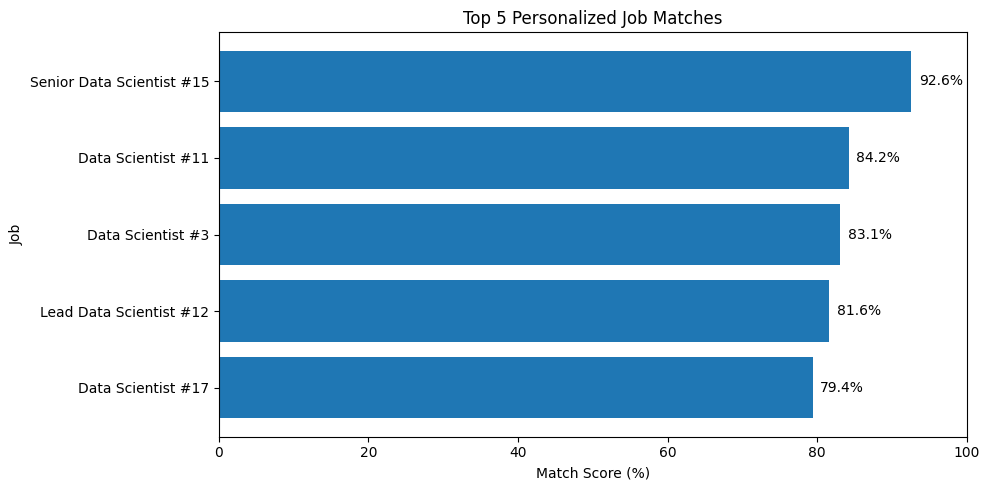

In [139]:
# Visualize Top 5 Final Match Scores

import matplotlib.pyplot as plt

plot_data = final_results_df.head(5).copy()

labels = [
    f"{row['title']} #{int(row['candidate_id'])}"
    for _, row in plot_data.iterrows()
]

plt.figure(figsize=(10, 5))

plt.barh(
    labels[::-1],
    plot_data["match_percent"][::-1]
)

plt.xlabel("Match Score (%)")
plt.ylabel("Job")
plt.title("Top 5 Personalized Job Matches")

plt.xlim(0, 100)

for i, score in enumerate(plot_data["match_percent"][::-1]):
    plt.text(
        score + 1,
        i,
        f"{score:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

In [140]:
# Create Human-AI Co-Design Review Table

human_review_df = final_results_df.head(5)[
    [
        "candidate_id",
        "title",
        "match_percent",
        "match_tier",
        "recommendation",
        "eligibility_status"
    ]
].copy()

# AI recommendation is preserved separately
human_review_df = human_review_df.rename(
    columns={"recommendation": "ai_recommendation"}
)

# Fields that will eventually be controlled by the human
human_review_df["human_decision"] = "Pending Review"
human_review_df["human_notes"] = ""
human_review_df["final_decision"] = human_review_df["ai_recommendation"]

display(human_review_df)

,candidate_id,title,match_percent,match_tier,ai_recommendation,eligibility_status,human_decision,human_notes,final_decision
0,15,Senior Data Scientist,92.6,Strong match,Apply,No hard eligibility identified,Pending Review,,Apply
1,11,Data Scientist,84.2,Strong match,Apply,No hard eligibility identified,Pending Review,,Apply
2,3,Data Scientist,83.1,Strong match,Apply,No hard eligibility identified,Pending Review,,Apply
3,12,Lead Data Scientist,81.6,Strong match,Consider - Check Eligibility,Human review required,Pending Review,,Consider - Check Eligibility
4,17,Data Scientist,79.4,Good match,Consider,No hard eligibility identified,Pending Review,,Consider


In [141]:
# Apply Human Review Decisions to Final Recommendations

def apply_human_decision(ai_recommendation, human_decision):
    if human_decision == "Accept AI":
        return ai_recommendation

    elif human_decision == "Apply":
        return "Apply"

    elif human_decision == "Consider":
        return "Consider"

    elif human_decision == "Reject":
        return "Do Not Apply"

    elif human_decision == "Review Eligibility":
        return "Review Eligibility First"

    else:
        return ai_recommendation


# Example review choices for demonstration
# These can later become interactive Streamlit controls.
human_review_df["human_decision"] = [
    "Accept AI",
    "Accept AI",
    "Accept AI",
    "Review Eligibility",
    "Consider"
]

human_review_df["final_decision"] = human_review_df.apply(
    lambda row: apply_human_decision(
        row["ai_recommendation"],
        row["human_decision"]
    ),
    axis=1
)

display(human_review_df)

,candidate_id,title,match_percent,match_tier,ai_recommendation,eligibility_status,human_decision,human_notes,final_decision
0,15,Senior Data Scientist,92.6,Strong match,Apply,No hard eligibility identified,Accept AI,,Apply
1,11,Data Scientist,84.2,Strong match,Apply,No hard eligibility identified,Accept AI,,Apply
2,3,Data Scientist,83.1,Strong match,Apply,No hard eligibility identified,Accept AI,,Apply
3,12,Lead Data Scientist,81.6,Strong match,Consider - Check Eligibility,Human review required,Review Eligibility,,Review Eligibility First
4,17,Data Scientist,79.4,Good match,Consider,No hard eligibility identified,Consider,,Consider
